In [ ]:
install.packages(c(
  "tidyverse",
  "tsibble",
  "fable",
  "fabletools",
  "feasts",
  "tseries"
))

In [ ]:
library(tidyverse)
library(tsibble)
library(fable)
library(fabletools)
library(feasts)
library(tseries)

# Adathalmaz leírása
Az elemzett adathalmaz részletes információkat nyújt az alkoholfogyasztási szokásokról az Egyesült Államokban, különös tekintettel az egy főre jutó etanolfogyasztásra különböző italtípusok szerint. Az adatok az 1977 és 2023 közötti időszakot fedik le, és az USA minden egyes államára tartalmaznak megfigyeléseket. Minden állam és év esetében az adathalmaz rögzíti a sörből, borból és tömény italokból származó, egy főre jutó tiszta etanolfogyasztást, valamint a teljes alkoholfogyasztást.

Az adathalmaz egyik kulcsfontosságú jellemzője, hogy lehetővé teszi mind az idősoros, mind a keresztmetszeti elemzést. Ezáltal vizsgálhatók az alkoholfogyasztás hosszú távú trendjei, az államok közötti különbségek, valamint az egyes italtípusok relatív jelentőségének időbeli változásai.

A projekt célja az egy főre jutó alkoholfogyasztás alakulásának elemzése idősorelemzési módszerekkel. Az elemzés a hosszú távú trendek azonosítására, az alkoholfogyasztás dinamikájának megértésére, valamint annak vizsgálatára fókuszál, hogy miként változott az összetétel (sör, bor, tömény italok) az idő során. Ezek az eredmények hozzájárulhatnak a társadalmi fogyasztási minták jobb megértéséhez, és támogathatják a megalapozottabb döntéshozatalt a közegészségügy és a szakpolitika területén.

## Adathalmaz forrása
> https://www.kaggle.com/datasets/sanaijlalshahrukh/us-alcohol-consumption-by-state-19772023

## Változók
- **state**: Az amerikai állam rövidítése  
- **state_name**: Az állam teljes neve  
- **year**: A megfigyelés éve (1977–2023)  
- **ethanol_beer_gallons_per_capita**: Egy főre jutó tiszta etanolfogyasztás sörből (gallonban)  
- **ethanol_wine_gallons_per_capita**: Egy főre jutó tiszta etanolfogyasztás borból (gallonban)  
- **ethanol_spirit_gallons_per_capita**: Egy főre jutó tiszta etanolfogyasztás tömény italokból (gallonban)  
- **ethanol_all_drinks_gallons_per_capita**: Az összes italtípusból származó teljes egy főre jutó tiszta etanolfogyasztás (gallonban)  
- **number_of_beers**: Egy főre jutó elfogyasztott standard sörök száma  
- **number_of_glasses_wine**: Egy főre jutó elfogyasztott standard pohár borok száma  
- **number_of_shots_liquor**: Egy főre jutó elfogyasztott standard tömény ital adagok száma  
- **number_of_drinks_total**: Egy főre jutó összes elfogyasztott standard alkoholos ital száma

---

# Adatok beolvasása
> A `year` változó egész számként (integer) van kezelve.

In [3]:
alcohol_consumption = read_csv("niaaa_apparent_per_capita_consumption_1977_2023.csv", col_types=list(year = col_integer()))
head(alcohol_consumption)

state,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita,number_of_beers,number_of_glasses_wine,number_of_shots_liquor,number_of_drinks_total
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
alabama,Alabama,1977,0.97,0.12,0.82,1.92,229.9259,23.8140,170.2514,409.6000
alabama,Alabama,1978,0.95,0.12,0.85,1.92,225.1852,23.8140,176.4801,409.6000
alabama,Alabama,1979,0.96,0.12,0.82,1.90,227.5556,23.8140,170.2514,405.3333
alabama,Alabama,1980,0.95,0.16,0.74,1.86,225.1852,31.7519,153.6415,396.8000
alabama,Alabama,1981,1.00,0.19,0.73,1.91,237.0370,37.7054,151.5653,407.4667
alabama,Alabama,1982,1.00,0.18,0.72,1.90,237.0370,35.7209,149.4891,405.3333


## Adattisztítási döntések

* Csak egy államazonosítót tartunk meg; a `state` változó eltávolításra kerül.
* Az aggregált `total` változó eltávolításra kerül.
* Hiányzó értékek (NA) ellenőrzése.
* Duplikált (`state_name`, `year`) párok ellenőrzése.

In [4]:
alcohol_consumption <- alcohol_consumption %>%
  select(
    -state,
    -number_of_drinks_total
  )

# NA check
na_check <- alcohol_consumption %>%
  summarise(across(everything(), ~sum(is.na(.)))) %>%
  summarise(total_na = sum(across(everything()))) %>%
  pull(total_na)

cat("NA check:", ifelse(na_check == 0, "PASS", "FAIL"), "\n")

# Duplicate  (state_name, year) check
dup_check <- alcohol_consumption %>%
  count(state_name, year) %>%
  filter(n > 1) %>%
  nrow()

cat("Duplicate (state_name, year) check:", ifelse(dup_check == 0, "PASS", "FAIL"), "\n")

NA check: PASS 
Duplicate (state_name, year) check: PASS 


In [5]:
summary(alcohol_consumption)

  state_name             year      ethanol_beer_gallons_per_capita
 Length:2632        Min.   :1977   Min.   :0.460                  
 Class :character   1st Qu.:1988   1st Qu.:1.100                  
 Mode  :character   Median :2000   Median :1.240                  
                    Mean   :2000   Mean   :1.257                  
                    3rd Qu.:2012   3rd Qu.:1.390                  
                    Max.   :2023   Max.   :2.170                  
 ethanol_wine_gallons_per_capita ethanol_spirit_gallons_per_capita
 Min.   :0.0800                  Min.   :0.360                    
 1st Qu.:0.2200                  1st Qu.:0.660                    
 Median :0.3200                  Median :0.790                    
 Mean   :0.3534                  Mean   :0.873                    
 3rd Qu.:0.4600                  3rd Qu.:0.990                    
 Max.   :1.2100                  Max.   :3.560                    
 ethanol_all_drinks_gallons_per_capita number_of_beers number_

**Ahogy látható nincsenek látványosan kiugró értékek.**

# Adatvizualizáció

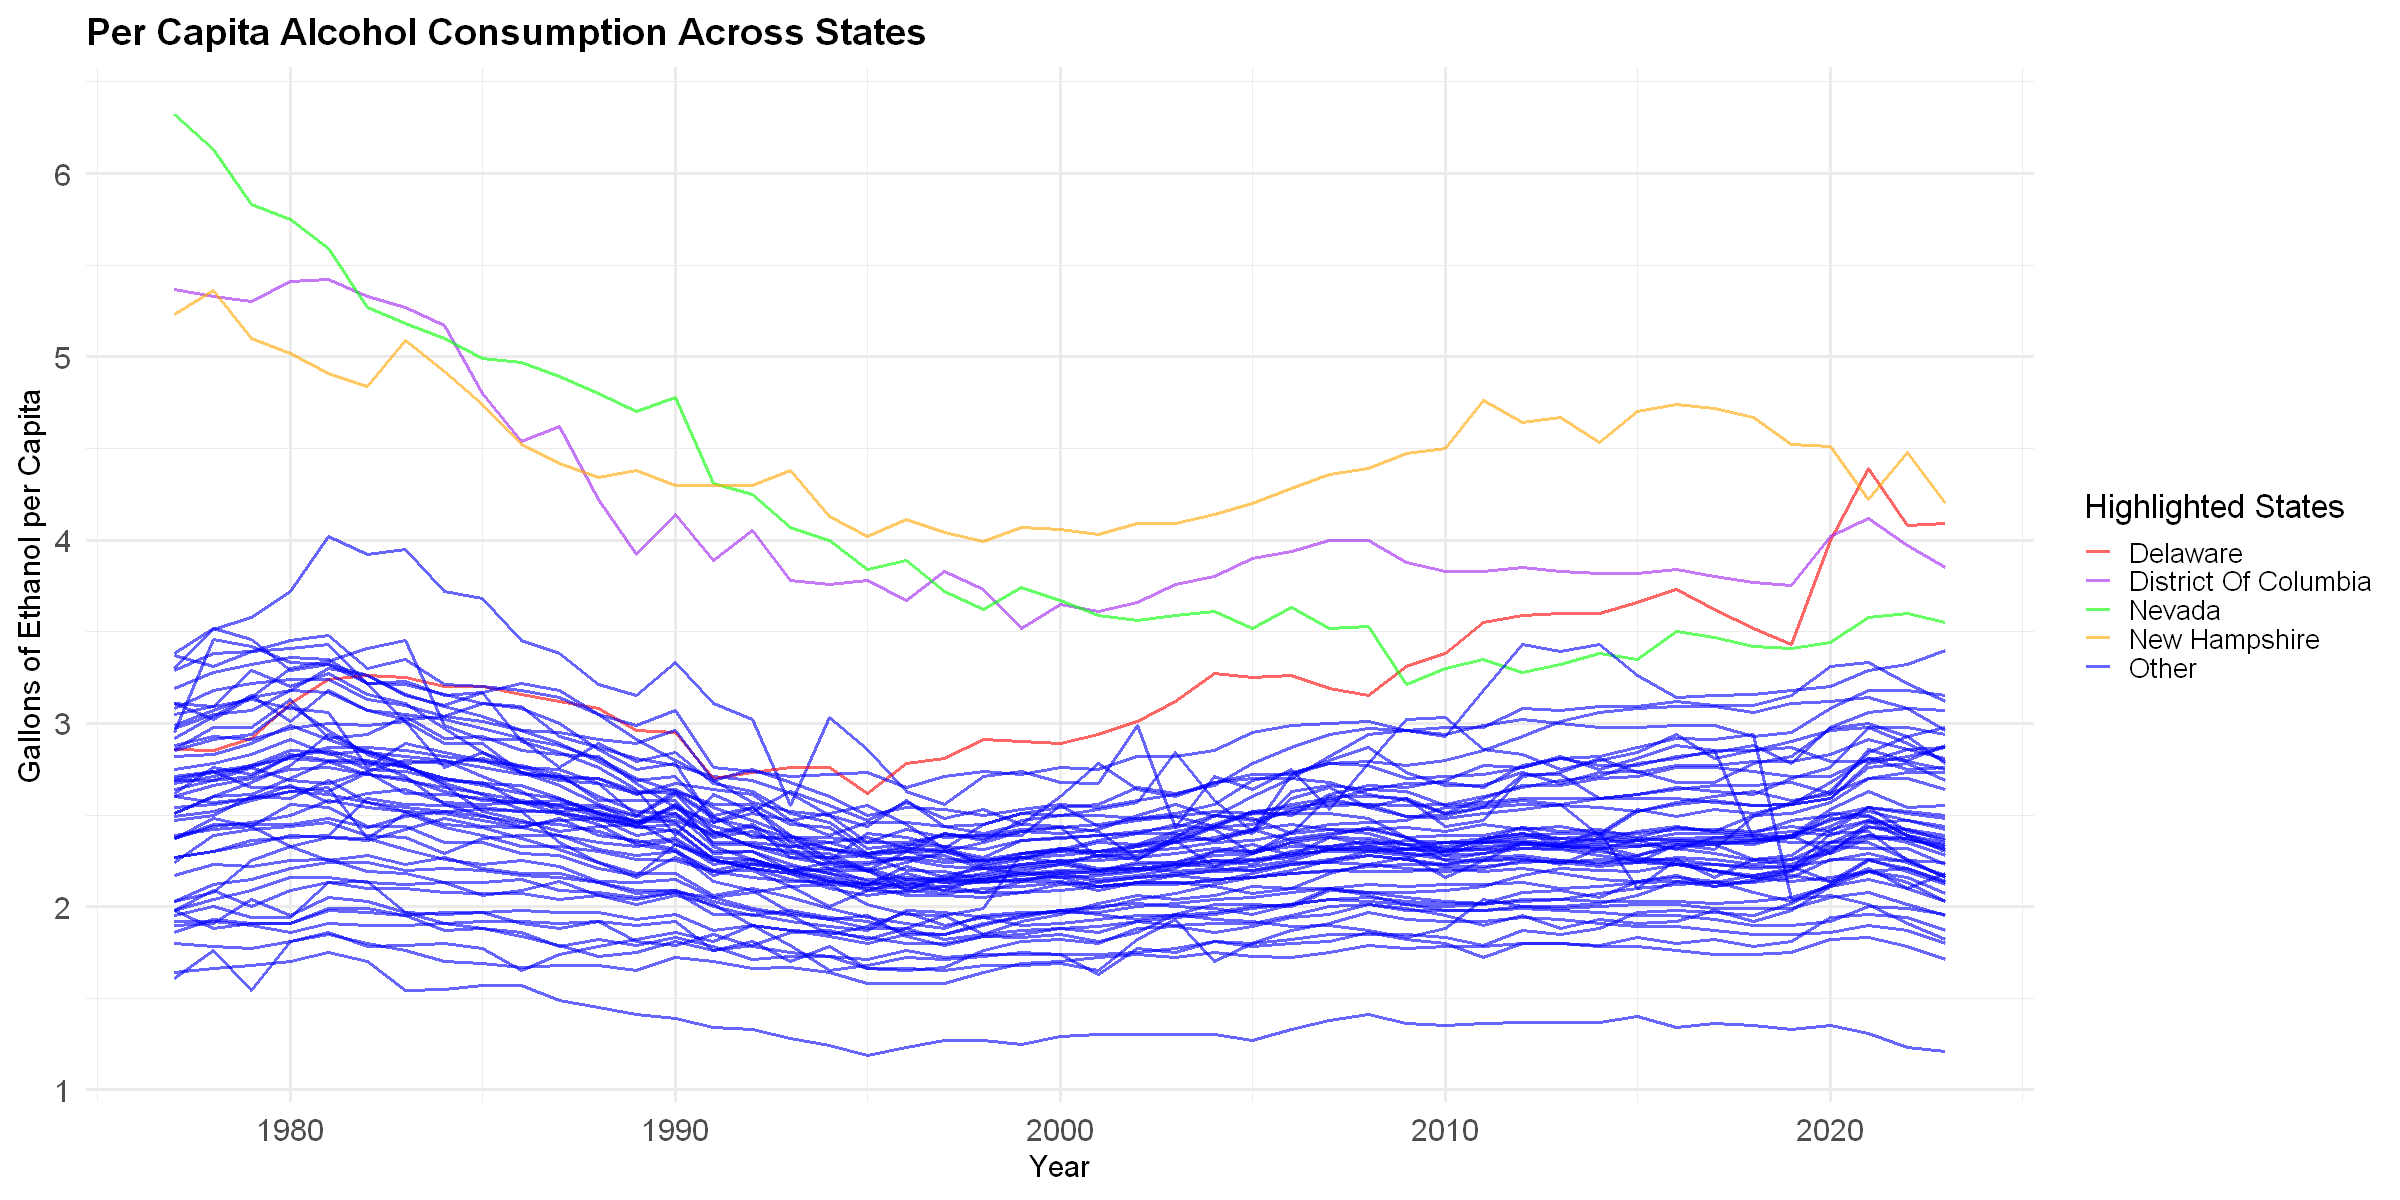

In [6]:
options(repr.plot.width = 20, repr.plot.height = 10)

# Top 4 állam meghatározása (max érték alapján)
top_states <- alcohol_consumption %>%
  group_by(state_name) %>%
  summarise(max_val = max(ethanol_all_drinks_gallons_per_capita, na.rm = TRUE)) %>%
  slice_max(max_val, n = 4) %>%
  pull(state_name)

alcohol_consumption %>%
  mutate(highlight = ifelse(state_name %in% top_states, state_name, "Other")) %>%
  ggplot(aes(x = year, y = ethanol_all_drinks_gallons_per_capita, group = state_name)) +
  geom_line(aes(color = highlight), alpha = 0.6) +
  scale_color_manual(
    values = c("Other" = "blue", setNames(c("green", "purple", "orange", "red"), top_states))
  ) +
  labs(
    title = "Per Capita Alcohol Consumption Across States",
    x = "Year",
    y = "Gallons of Ethanol per Capita",
    color = "Highlighted States"
  ) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(size = 22, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 18)
  )

Az ábra az Egyesült Államok mind az 50 államának egy főre jutó alkoholfogyasztását mutatja be az **1977 és 2023 közötti időszakban**.

A jobb áttekinthetőség érdekében a 4 legmagasabb fogyasztási értékkel rendelkező államot kiemeltem.

Ez a vizualizáció lehetővé teszi:
- az egyes államok közötti különbségek megfigyelését,
- a hosszú távú trendek összehasonlítását,
- valamint a kiugróan magas fogyasztási szintek azonosítását.

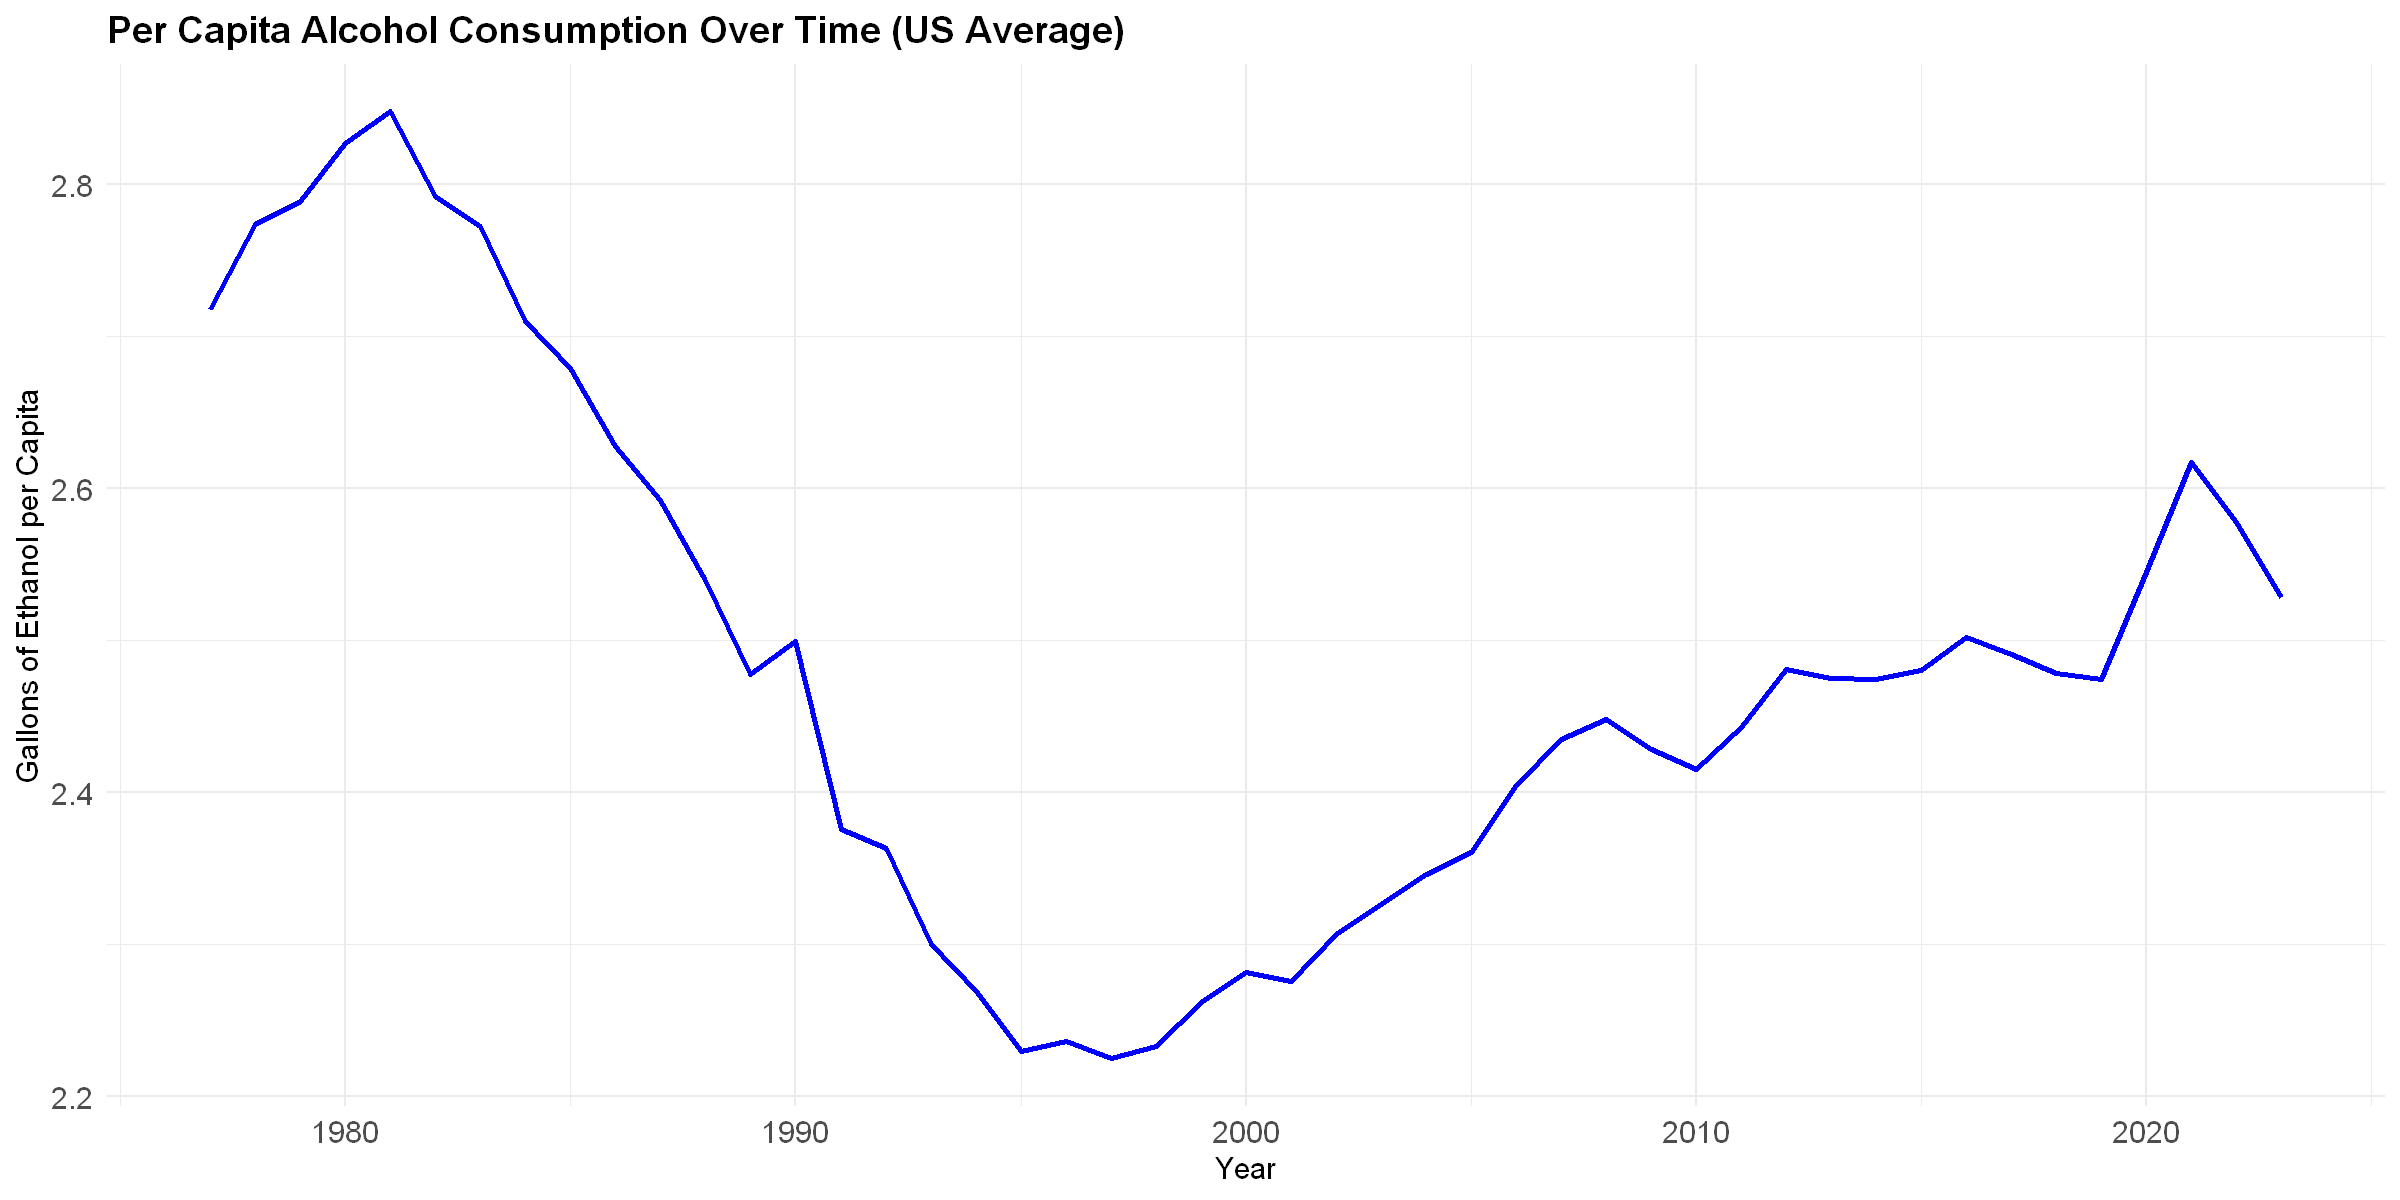

In [7]:
df_us <- alcohol_consumption %>%
  group_by(year) %>%
  summarise(total = mean(ethanol_all_drinks_gallons_per_capita, na.rm = TRUE))

df_us_ts <- df_us %>%
  as_tsibble(index = year)

df_us_ts %>%
  ggplot(aes(x = year, y = total)) +
  geom_line(color = "blue", linewidth = 1.6) +
  labs(
    title = "Per Capita Alcohol Consumption Over Time (US Average)",
    x = "Year",
    y = "Gallons of Ethanol per Capita"
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 18)
  )

Az ábra az Egyesült Államok **országos átlagos egy főre jutó alkoholfogyasztását** szemlélteti a 1977 és 2023 közötti időszakban.

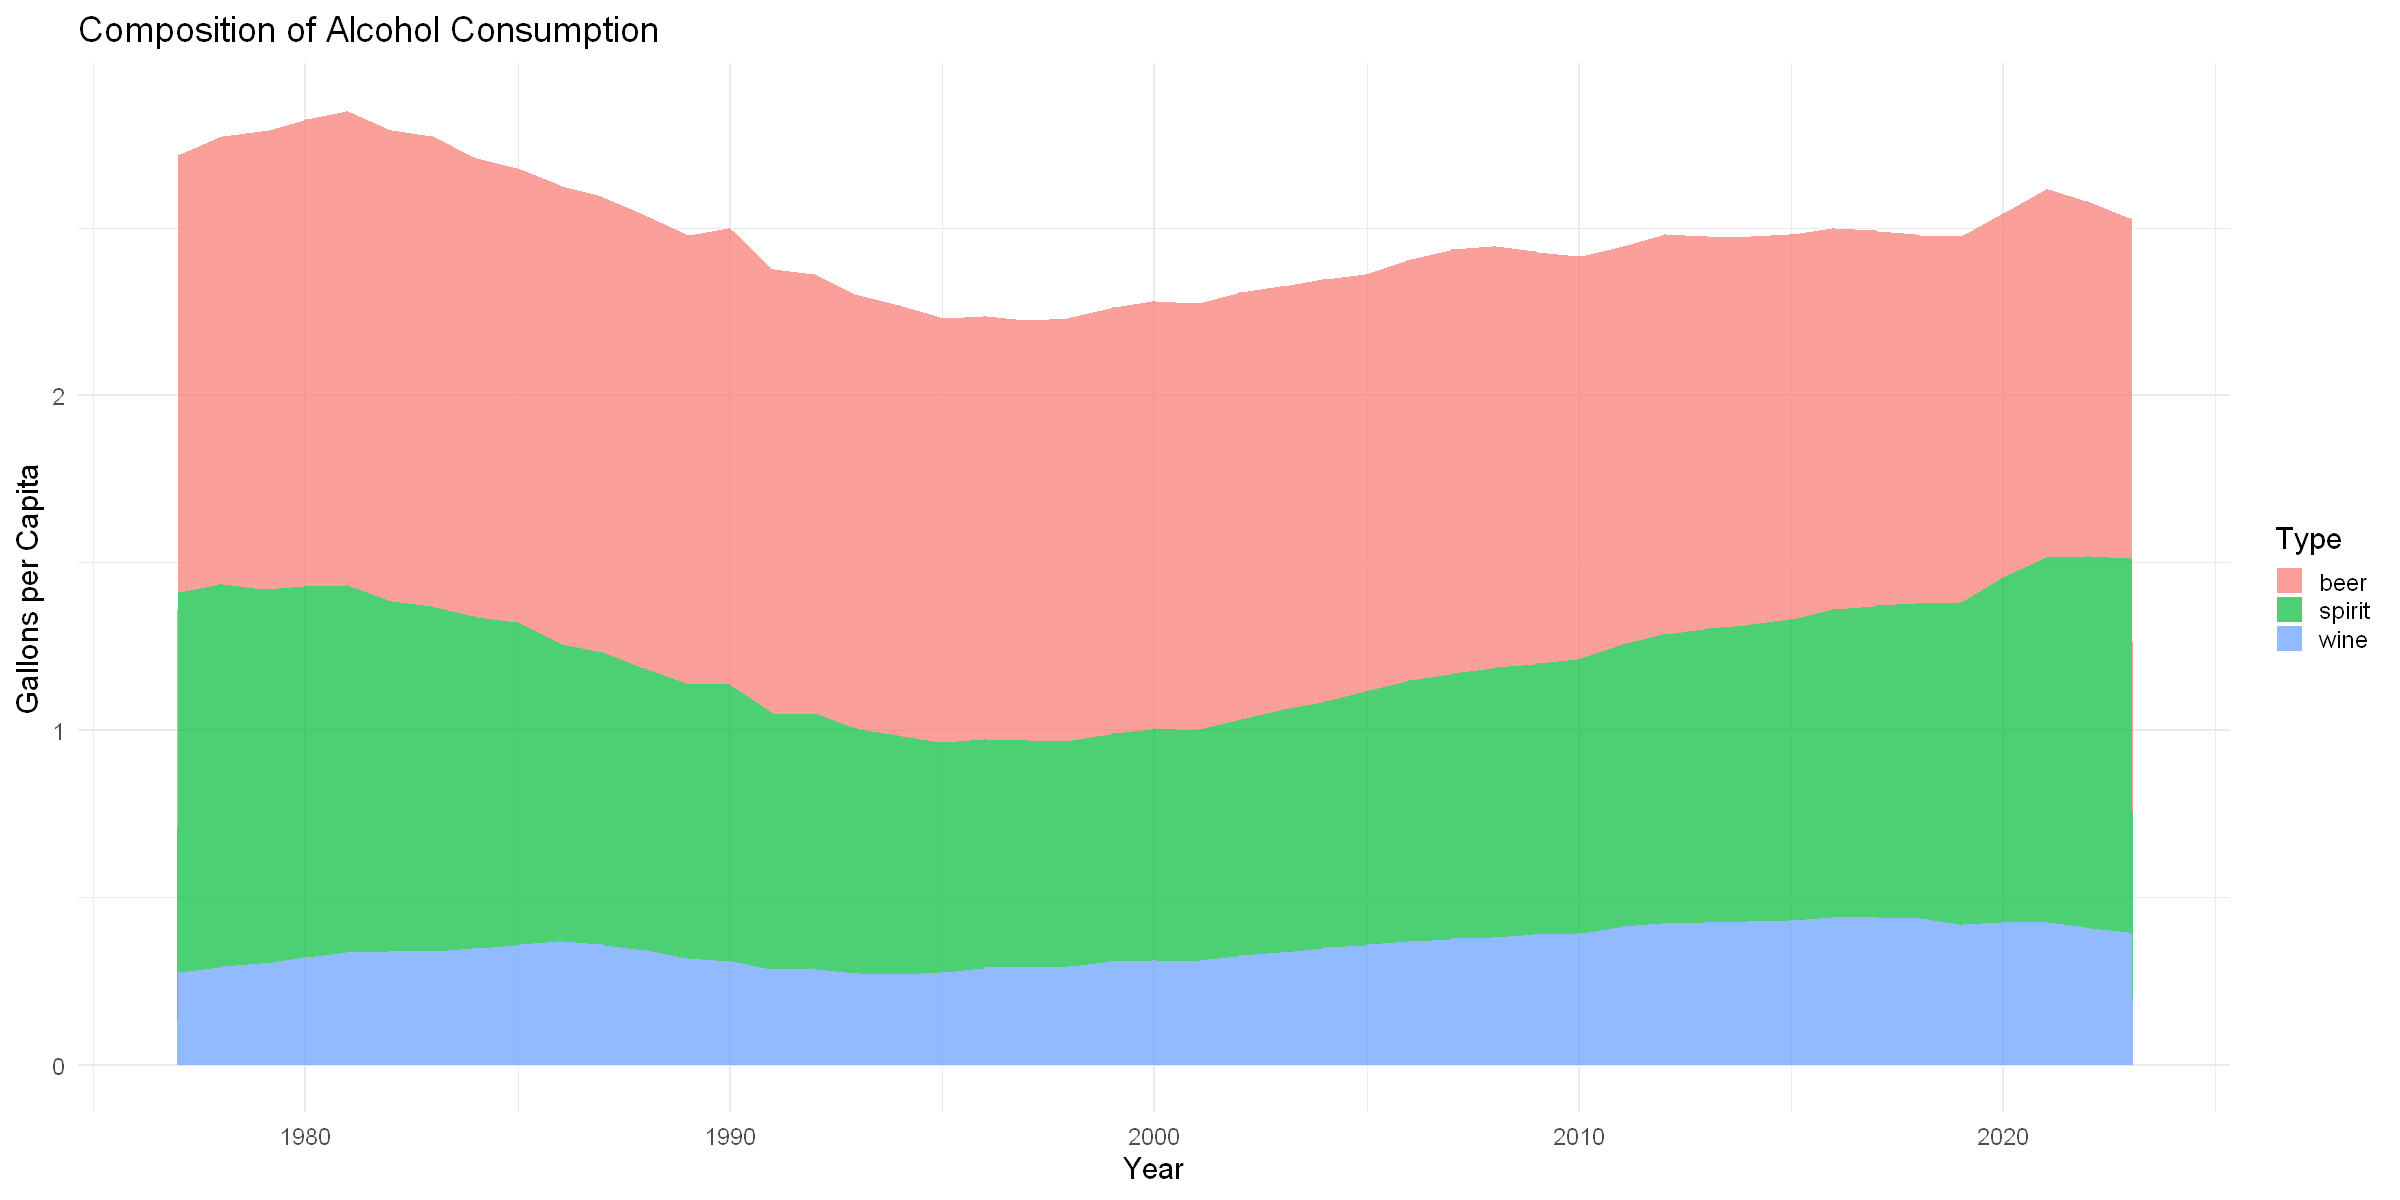

In [8]:
alcohol_consumption %>%
  group_by(year) %>%
  summarise(
    beer = mean(ethanol_beer_gallons_per_capita, na.rm = TRUE),
    wine = mean(ethanol_wine_gallons_per_capita, na.rm = TRUE),
    spirit = mean(ethanol_spirit_gallons_per_capita, na.rm = TRUE)
  ) %>%
  tidyr::pivot_longer(-year, names_to = "type", values_to = "value") %>%
  ggplot(aes(x = year, y = value, fill = type)) +
  geom_area(alpha = 0.7) +
  labs(
    title = "Composition of Alcohol Consumption",
    x = "Year",
    y = "Gallons per Capita",
    fill = "Type"
  ) +
  theme_minimal(base_size = 18)

Az ábra az USA átlagos alkoholfogyasztás összetételét mutatja be, külön feltüntetve a három fő alkoholtípus arányát.

Jól megfigyelhető, hogy a tömény italok fogyasztása nagyobb ingadozást mutat az időszak során, míg a sör és a bor fogyasztása viszonylag stabilabb.
Ez arra utal, hogy a fogyasztási szokások változása elsősorban a tömény italok esetében jelentősebb.

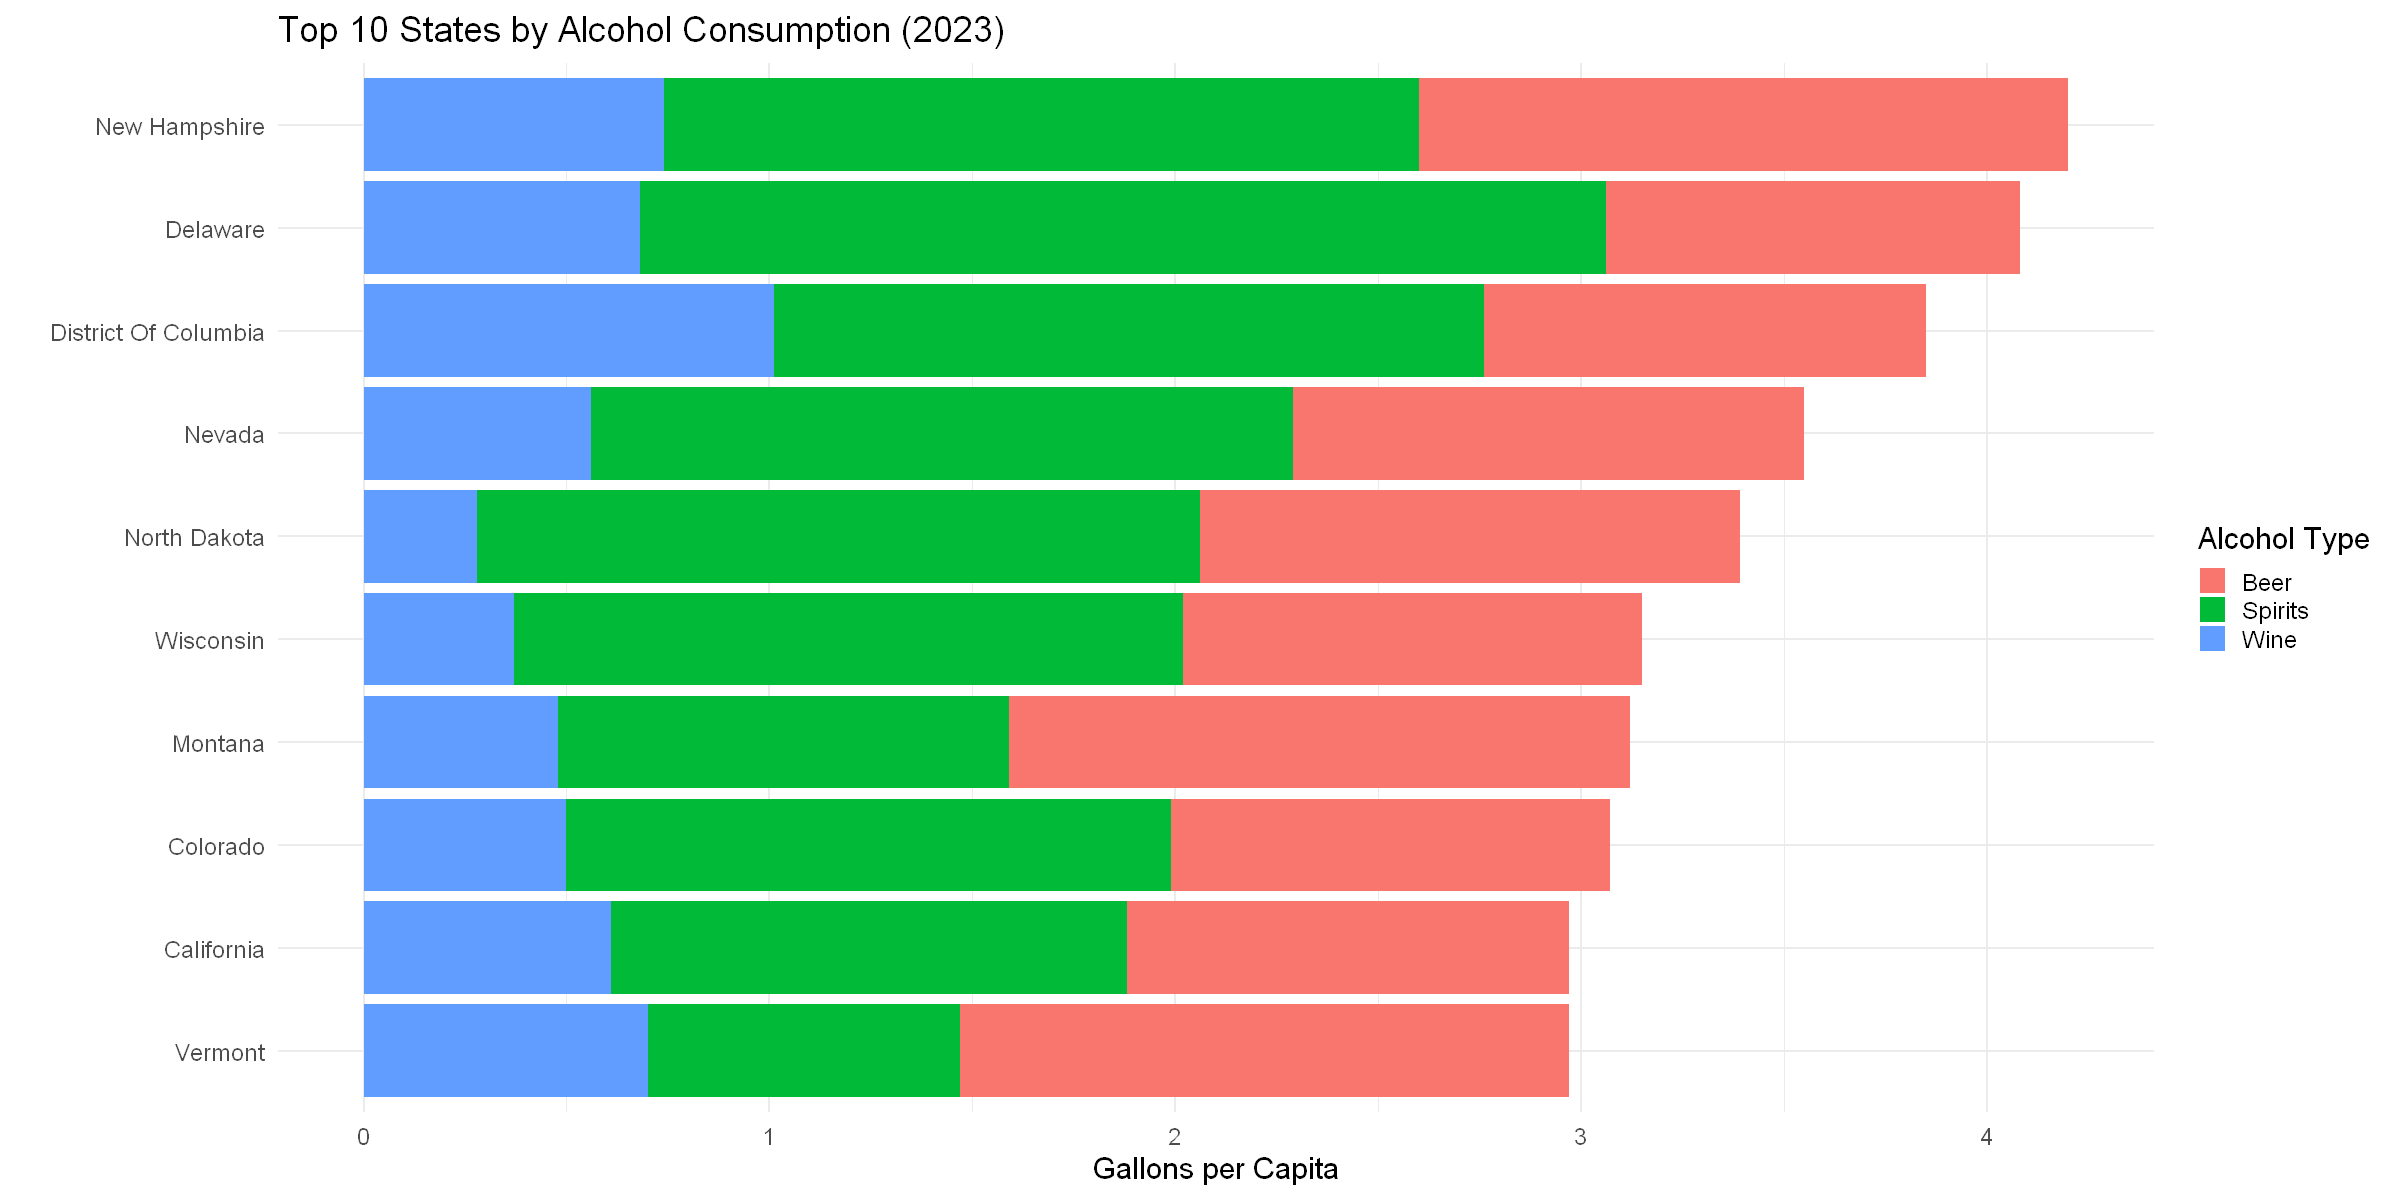

In [9]:
top10 <- alcohol_consumption %>%
  filter(year == 2023) %>%
  arrange(desc(ethanol_all_drinks_gallons_per_capita)) %>%
  slice_head(n = 10)

top10 %>%
  pivot_longer(
    cols = c(
      ethanol_beer_gallons_per_capita,
      ethanol_wine_gallons_per_capita,
      ethanol_spirit_gallons_per_capita
    ),
    names_to = "type",
    values_to = "value"
  ) %>%
  mutate(
    type = recode(
      type,
      ethanol_beer_gallons_per_capita = "Beer",
      ethanol_wine_gallons_per_capita = "Wine",
      ethanol_spirit_gallons_per_capita = "Spirits"
    )
  ) %>%
  ggplot(aes(
    x = reorder(state_name, ethanol_all_drinks_gallons_per_capita),
    y = value,
    fill = type
  )) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 States by Alcohol Consumption (2023)",
    x = "",
    y = "Gallons per Capita",
    fill = "Alcohol Type"
  ) +
  theme_minimal(base_size = 18)

Az ábra bemutatja, hogy **2023-ban a 10 legmagasabb alkoholfogyasztással rendelkező államban** hogyan oszlik meg az egyes italtípusok (sör, bor, tömény italok) aránya.

Az eredmények alapján megfigyelhető, hogy a tömény italok aránya magasabb azokban az államokban, ahol az összesített alkoholfogyasztás is kiemelkedő.  
Ez arra utal, hogy a nagyobb fogyasztás részben a tömény italok intenzívebb jelenlétével magyarázható.

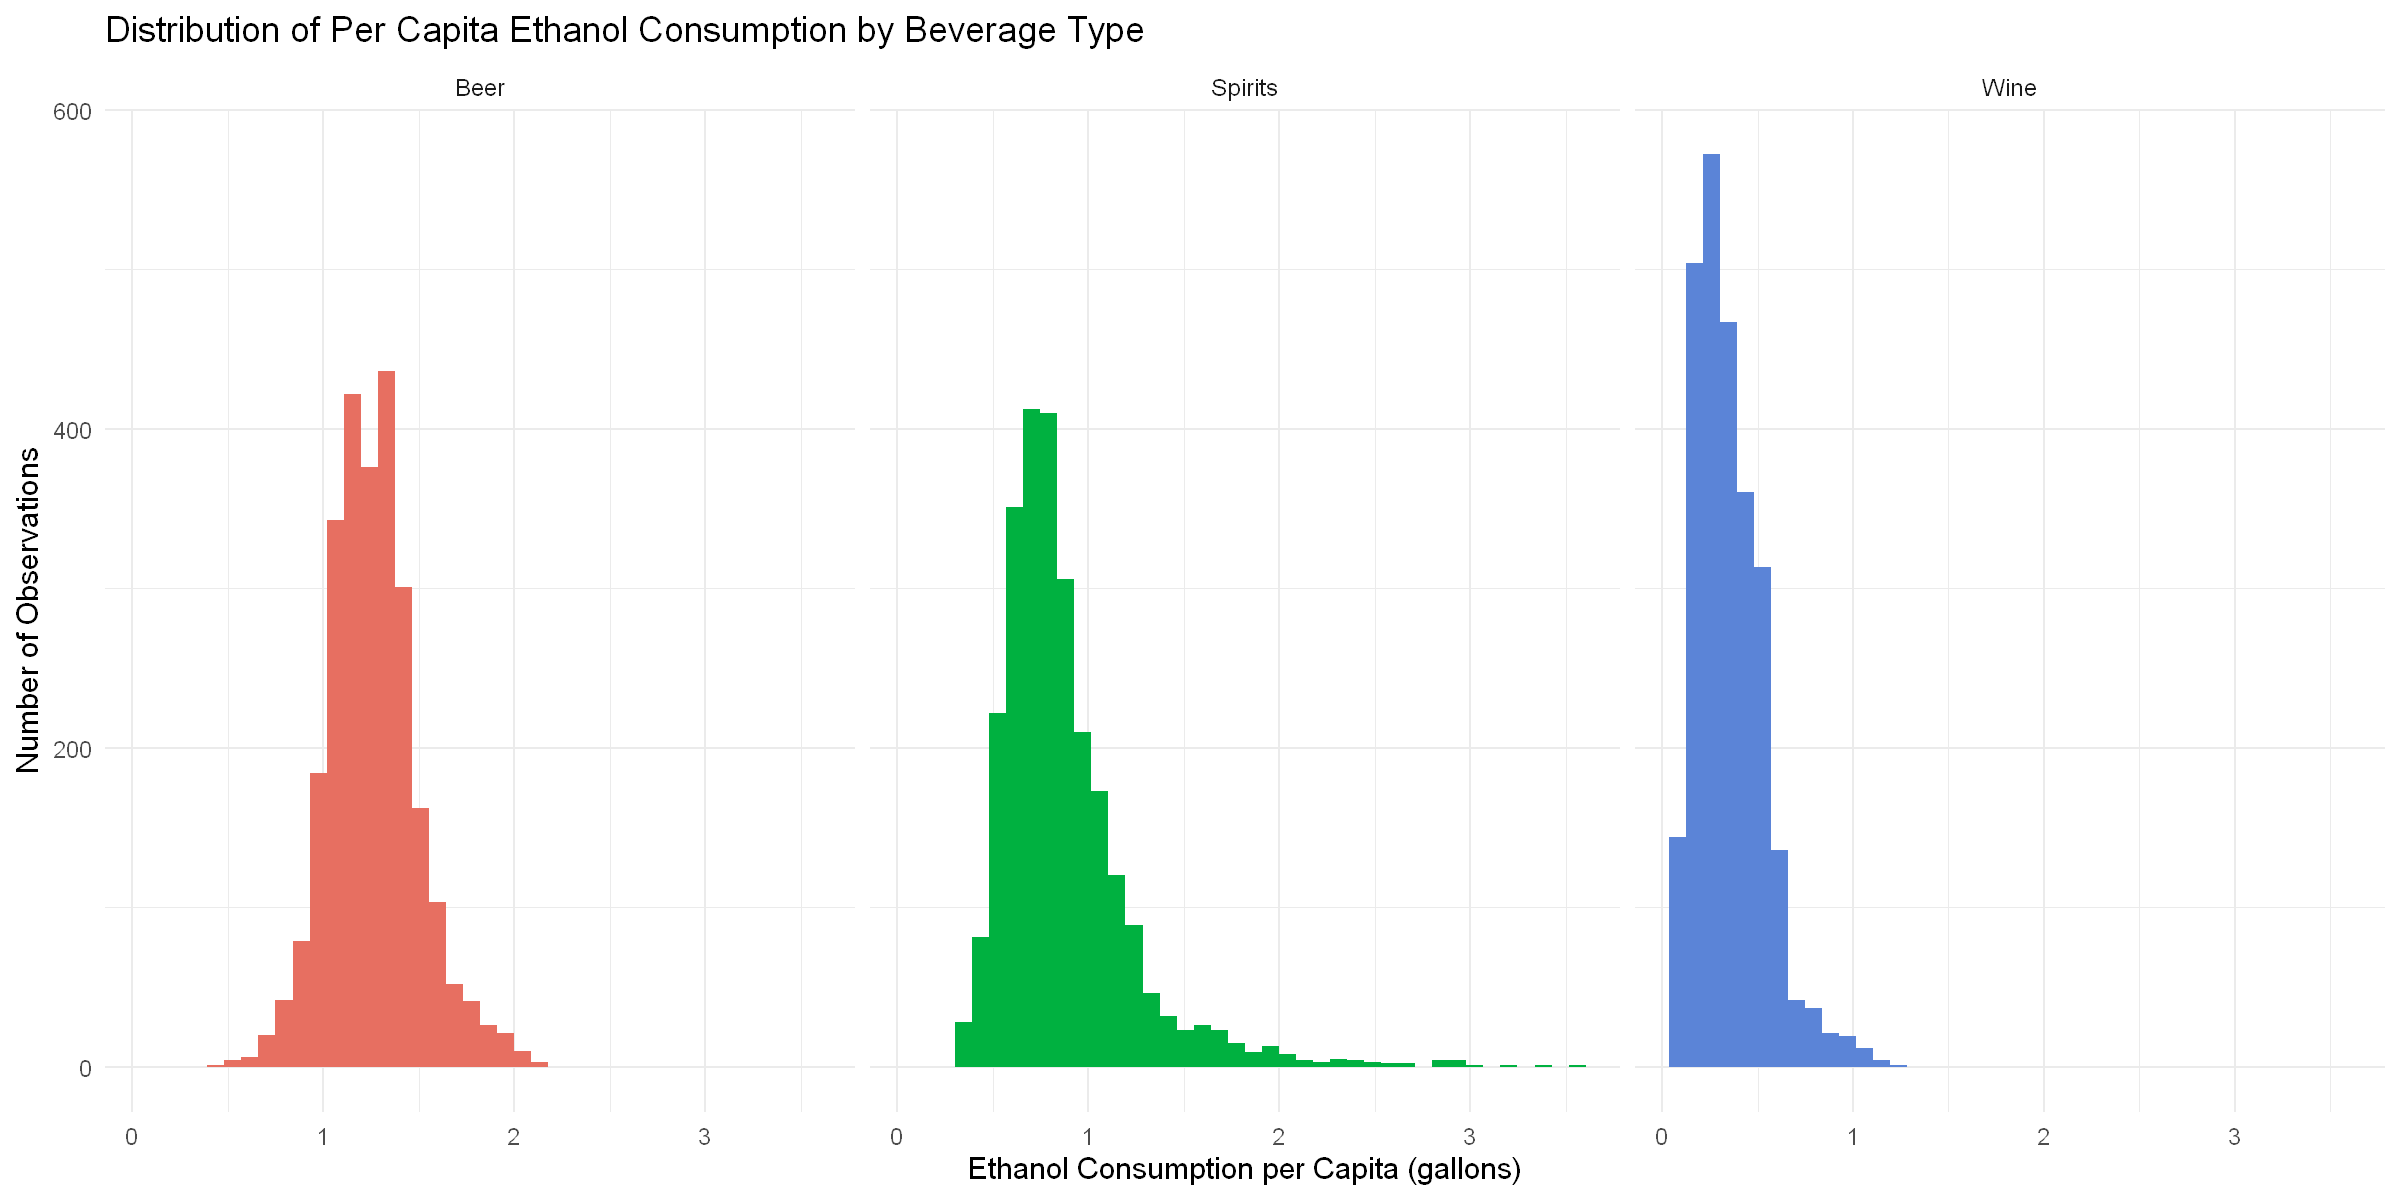

In [10]:
alcohol_consumption %>%
  pivot_longer(
    cols = c(
      ethanol_beer_gallons_per_capita,
      ethanol_wine_gallons_per_capita,
      ethanol_spirit_gallons_per_capita
    ),
    names_to = "drink_type",
    values_to = "ethanol"
  ) %>%
  mutate(
    drink_type = recode(
      drink_type,
      ethanol_beer_gallons_per_capita = "Beer",
      ethanol_wine_gallons_per_capita = "Wine",
      ethanol_spirit_gallons_per_capita = "Spirits"
    )
  ) %>%
  filter(ethanol > 0) %>%
  ggplot(aes(x = ethanol, fill = drink_type)) +
  geom_histogram(bins = 40) +
  facet_wrap(~drink_type, nrow = 1) +
  scale_fill_manual(
    values = c(
      "Beer" = "#e76f61",
      "Spirits" = "#00b140",
      "Wine" = "#5b84d7"
    )
  ) +
  labs(
    title = "Distribution of Per Capita Ethanol Consumption by Beverage Type",
    x = "Ethanol Consumption per Capita (gallons)",
    y = "Number of Observations"
  ) +
  theme_minimal(base_size = 18) +
  theme(legend.position = "none")

Az ábra az egy főre jutó alkoholfogyasztás eloszlását mutatja a három fő italtípus (sör, bor, tömény italok) esetében.

A hisztogramok alapján látható, hogy a sör és a bor fogyasztása viszonylag kiegyensúlyozottabb és kisebb szórást mutat. Ezzel szemben a tömény italok eloszlása nagyobb variabilitást mutat, és az értékek jobban elnyúlnak a magasabb tartományok felé.
Összességében a tömény italok fogyasztása változékonyabb, míg a sör és a bor stabilabb mintázatot követ.

---

# Idősorelemzés

Az elemzés során három eltérő megközelítést alkalmazok:
- **ARIMA (AutoRegressive Integrated Moving Average)** modell, amely az idősor belső időbeli függőségeit ragadja meg,
- **ETS (Error–Trend–Seasonality)** modell, amely a sorozat komponenseire (szint, trend, esetleges szezonalitás) épít,
- **TSLM (Time Series Linear Model)**, amely egy egyszerűbb, lineáris trendalapú megközelítést képvisel.



## Stacionaritás vizsgálata és előkészítés

Az idősorelemzés egyik alapvető feltétele a stacionaritás vizsgálata, különösen az ARIMA modellhez.

A stacionaritás ellenőrzésére az **Augmented Dickey–Fuller (ADF) tesztet** alkalmaztam:

In [11]:
# 1. Stacionaritás vizsgálata (ADF teszt)
adf.test(df_us_ts$total)


	Augmented Dickey-Fuller Test

data:  df_us_ts$total
Dickey-Fuller = -2.0852, Lag order = 3, p-value = 0.5401
alternative hypothesis: stationary


### Eredmények

> Az eredeti idősorra elvégzett ADF teszt alapján:
>
> - p-érték: **0.54**
>
> Ez azt jelenti, hogy a nullhipotézist (nem stacionárius folyamat) nem tudjuk elutasítani, tehát az idősor nem stacionárius, és ezért valószínűleg trendet tartalmaz.

Ezért Differenciálás kell:

In [12]:
# 2. Differenciálás
df_us_ts <- df_us_ts %>%
  mutate(diff_total = difference(total))

# 3. ADF teszt a differenciált sorra
adf.test(na.omit(df_us_ts$diff_total))


	Augmented Dickey-Fuller Test

data:  na.omit(df_us_ts$diff_total)
Dickey-Fuller = -3.2937, Lag order = 3, p-value = 0.0845
alternative hypothesis: stationary


> A kapott differenciált sorra ismét elvégezve az ADF tesztet
>- p-érték: **0.084**
>  
> Ez az érték már közelebb van a szokásos szignifikanciaszinthez, így a sorozat **közel stacionáriusnak tekinthető**, ami alkalmassá teszi a további modellezésre.

# 1. ARIMA - AutoRegressive Integrated Moving Average modell

In [13]:
fit <- df_us_ts %>%
  model(ARIMA(total))

report(fit)

Series: total 
Model: ARIMA(1,0,2) w/ mean 

Coefficients:
         ar1     ma1     ma2  constant
      0.9393  0.3219  0.3297    0.1533
s.e.  0.0444  0.1459  0.1560    0.0067

sigma^2 estimated as 0.001358:  log likelihood=88.86
AIC=-167.71   AICc=-166.25   BIC=-158.46


>Az automatikus modellillesztés eredményeként egy **ARIMA(1,0,2)** specifikációjú modell került kiválasztásra konstans taggal.
>
> Az AR(1) együttható magas értéke (~0.94) erős perzisztenciára utal, vagyis az alkoholfogyasztás aktuális értékei jelentős mértékben függnek az előző időszak értékeitől.

### 1.1 Reziduális vizsgálat

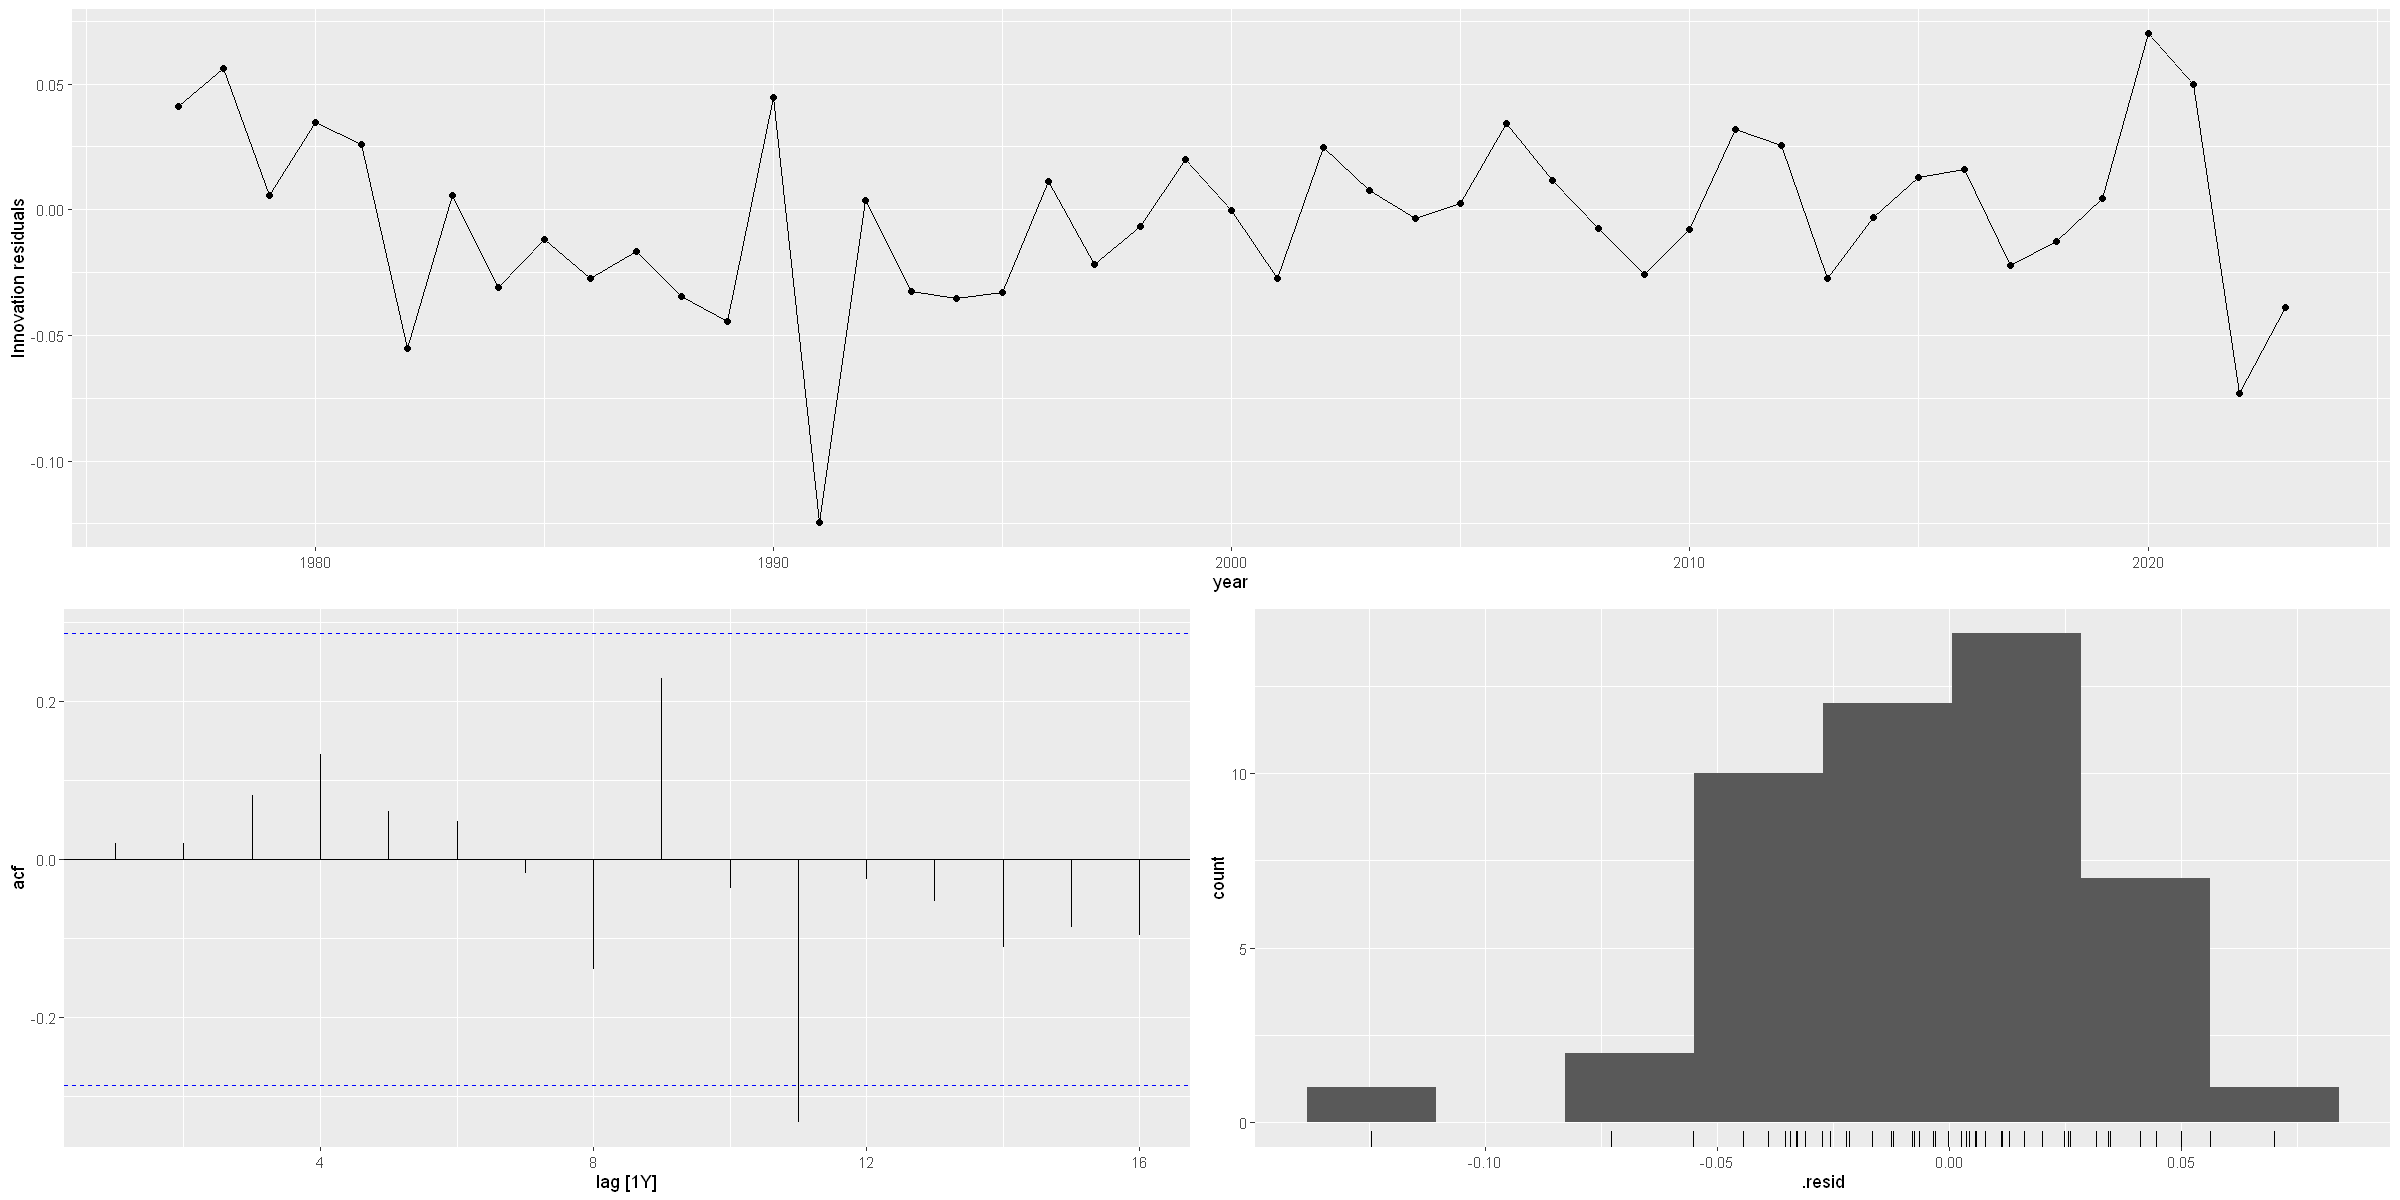

In [14]:
ggtime::gg_tsresiduals(fit)

Az ábra alapján megfigyelhető, hogy:
- a reziduálisok időben véletlenszerűen ingadoznak,
- nem mutatnak egyértelmű mintázatot,
- az autokorrelációk többsége a konfidencia-intervallumon belül marad.

Az ARIMA modell jól illeszkedik az adatokra, és képes kezelni az idősor dinamikáját, így alkalmas az alkoholfogyasztás előrejelzésére.

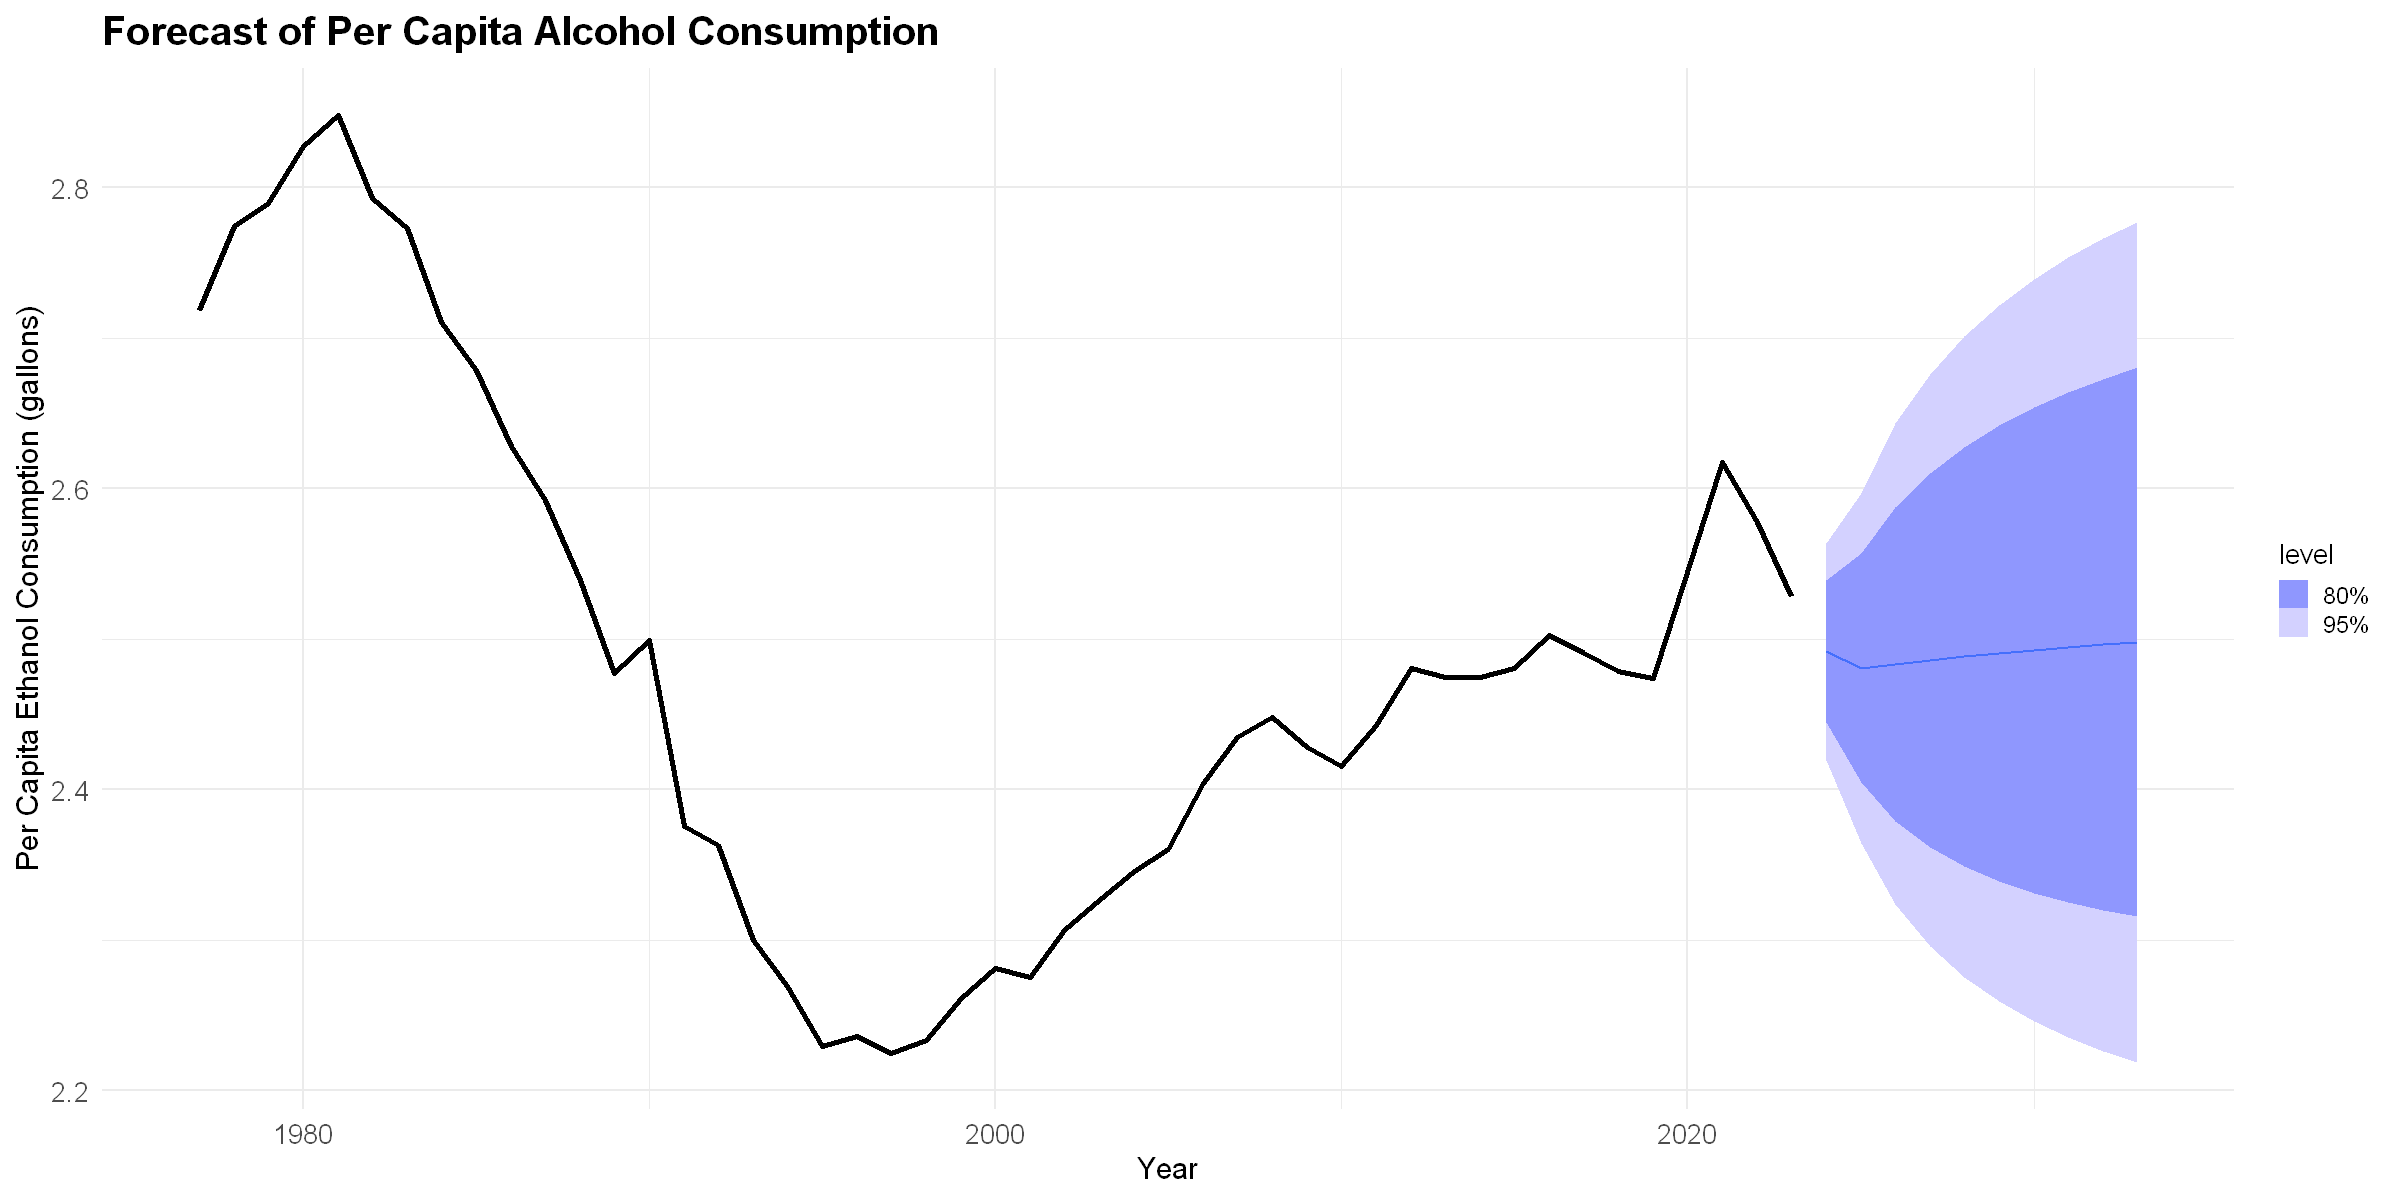

In [25]:
fc <- fit %>%
  forecast(h = 10)

ggtime::autoplot(fc, df_us_ts) +
  labs(
    title = "Forecast of Per Capita Alcohol Consumption",
    x = "Year",
    y = "Per Capita Ethanol Consumption (gallons)"
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 16)
  ) +
  # Vastagabb múltbeli vonal
  geom_line(
    data = df_us_ts,
    aes(x = year, y = total),
    linewidth = 1.5,
    color = "black"
  )

# 2. ETS Error – Trend – Seasonality modell

In [16]:
fit_ets <- df_us_ts %>%
  model(ETS(total))

report(fit_ets)

Series: total 
Model: ETS(M,Ad,N) 
  Smoothing parameters:
    alpha = 0.8717322 
    beta  = 0.4136789 
    phi   = 0.8000001 

  Initial states:
     l[0]      b[0]
 2.665429 0.0680901

  sigma^2:  2e-04

      AIC      AICc       BIC 
-125.6568 -123.5568 -114.5559 


>**Értelmezés:**
>- **α (alpha ≈ 0.87)**: magas érték, ami azt jelzi, hogy a modell erősen támaszkodik a legfrissebb megfigyelésekre,
>- **β (beta ≈ 0.41)**: a trend mérsékelt változását mutatja,
>- **φ (phi ≈ 0.8)**: a trend csillapított, vagyis hosszú távon a csökkenés üteme mérséklődik.

### ETS modell reziduális vizsgálata

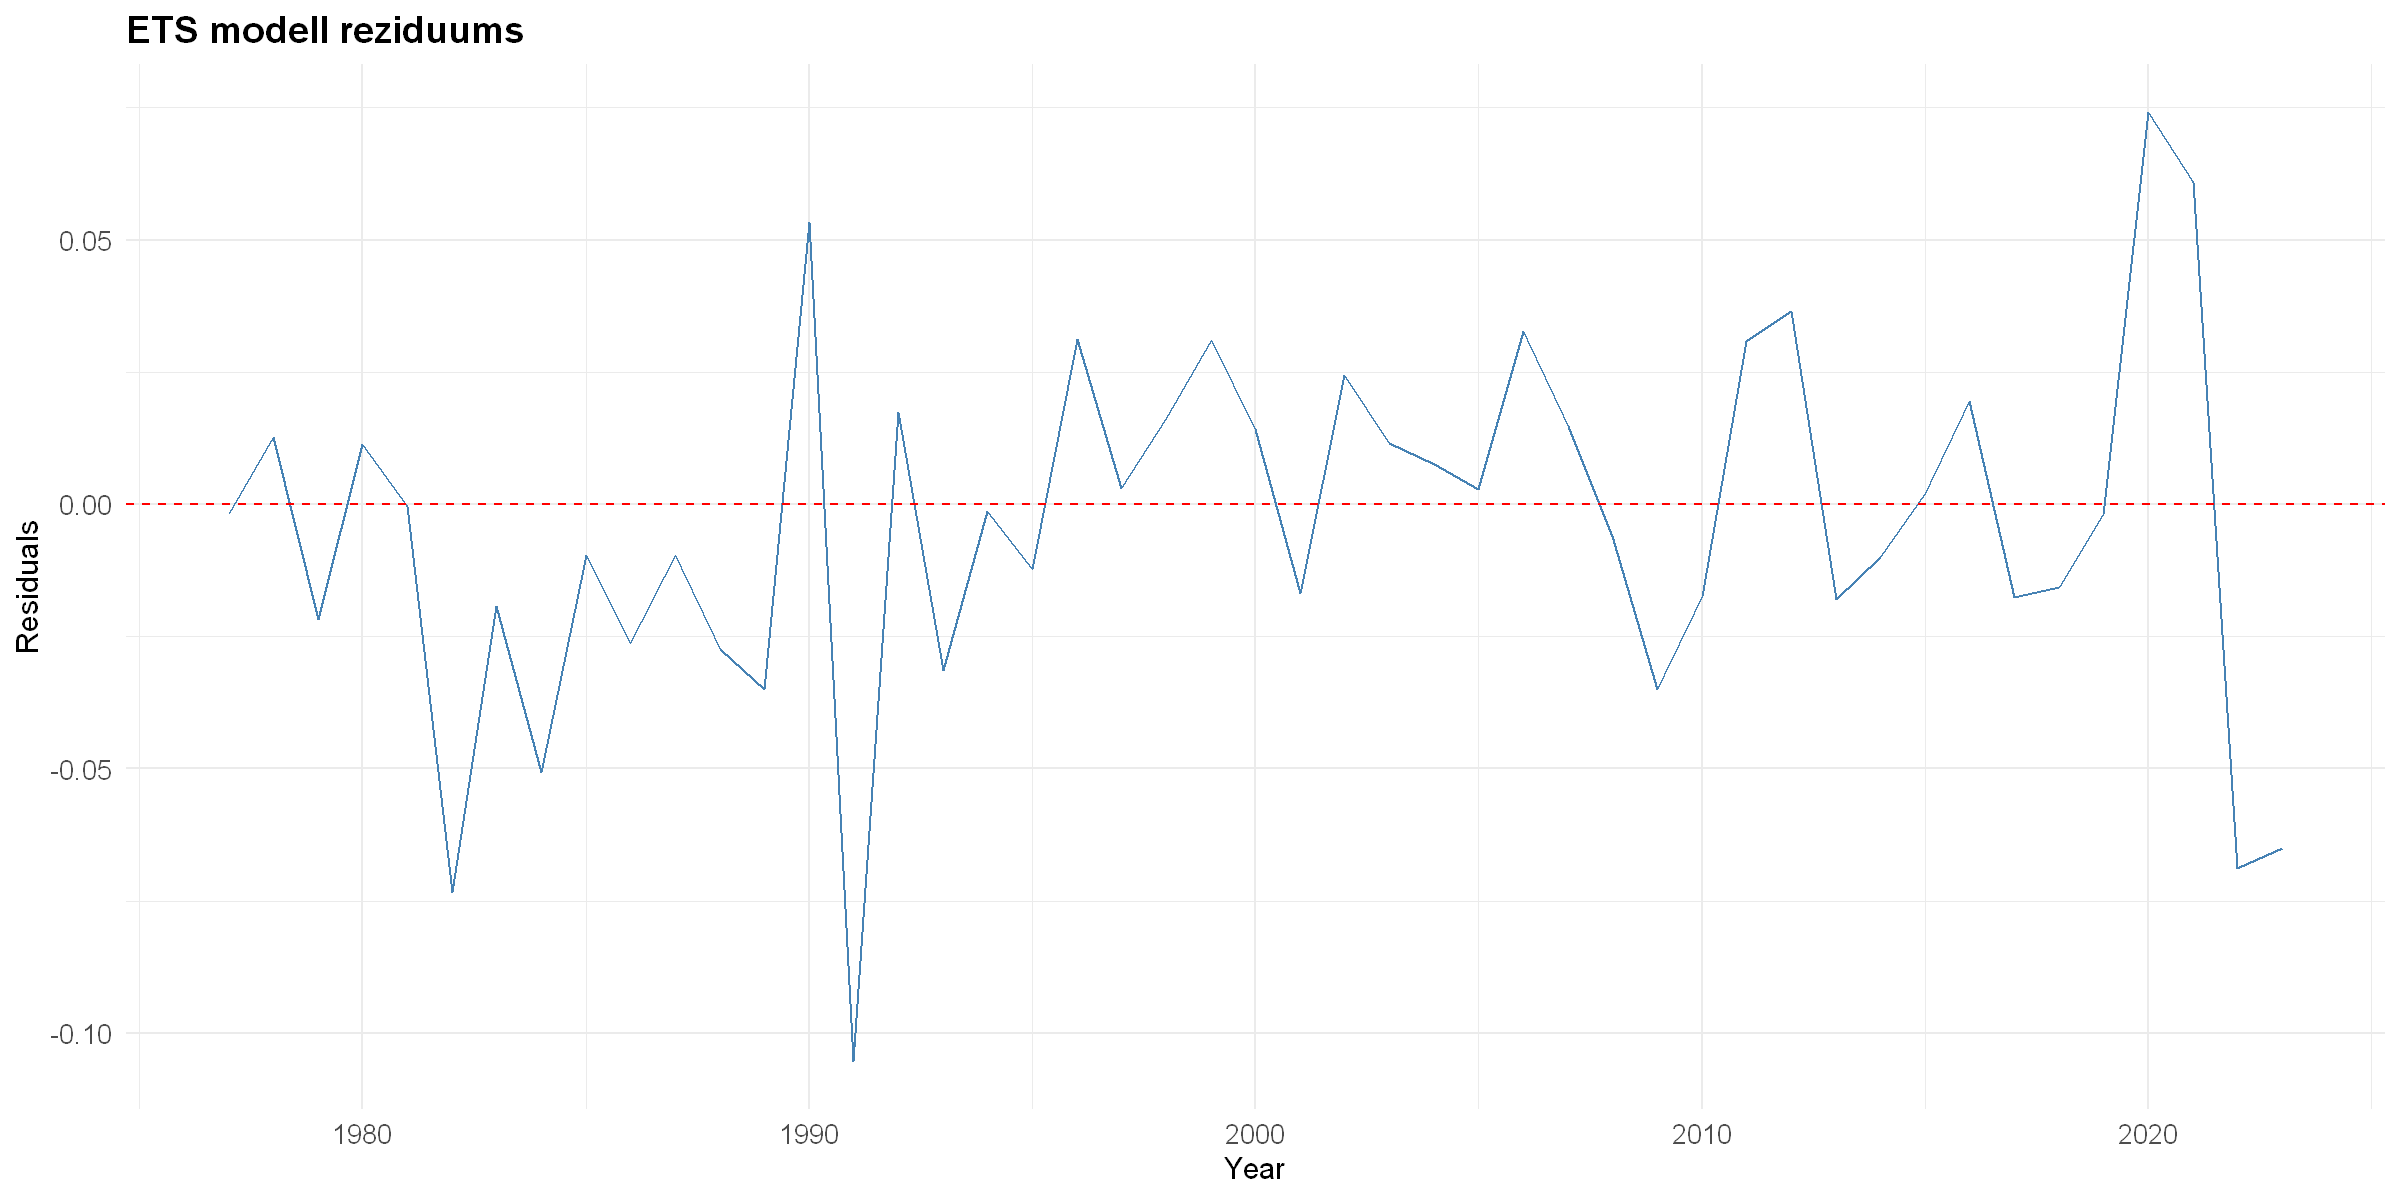

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
ETS(total),7.732886,0.6549098


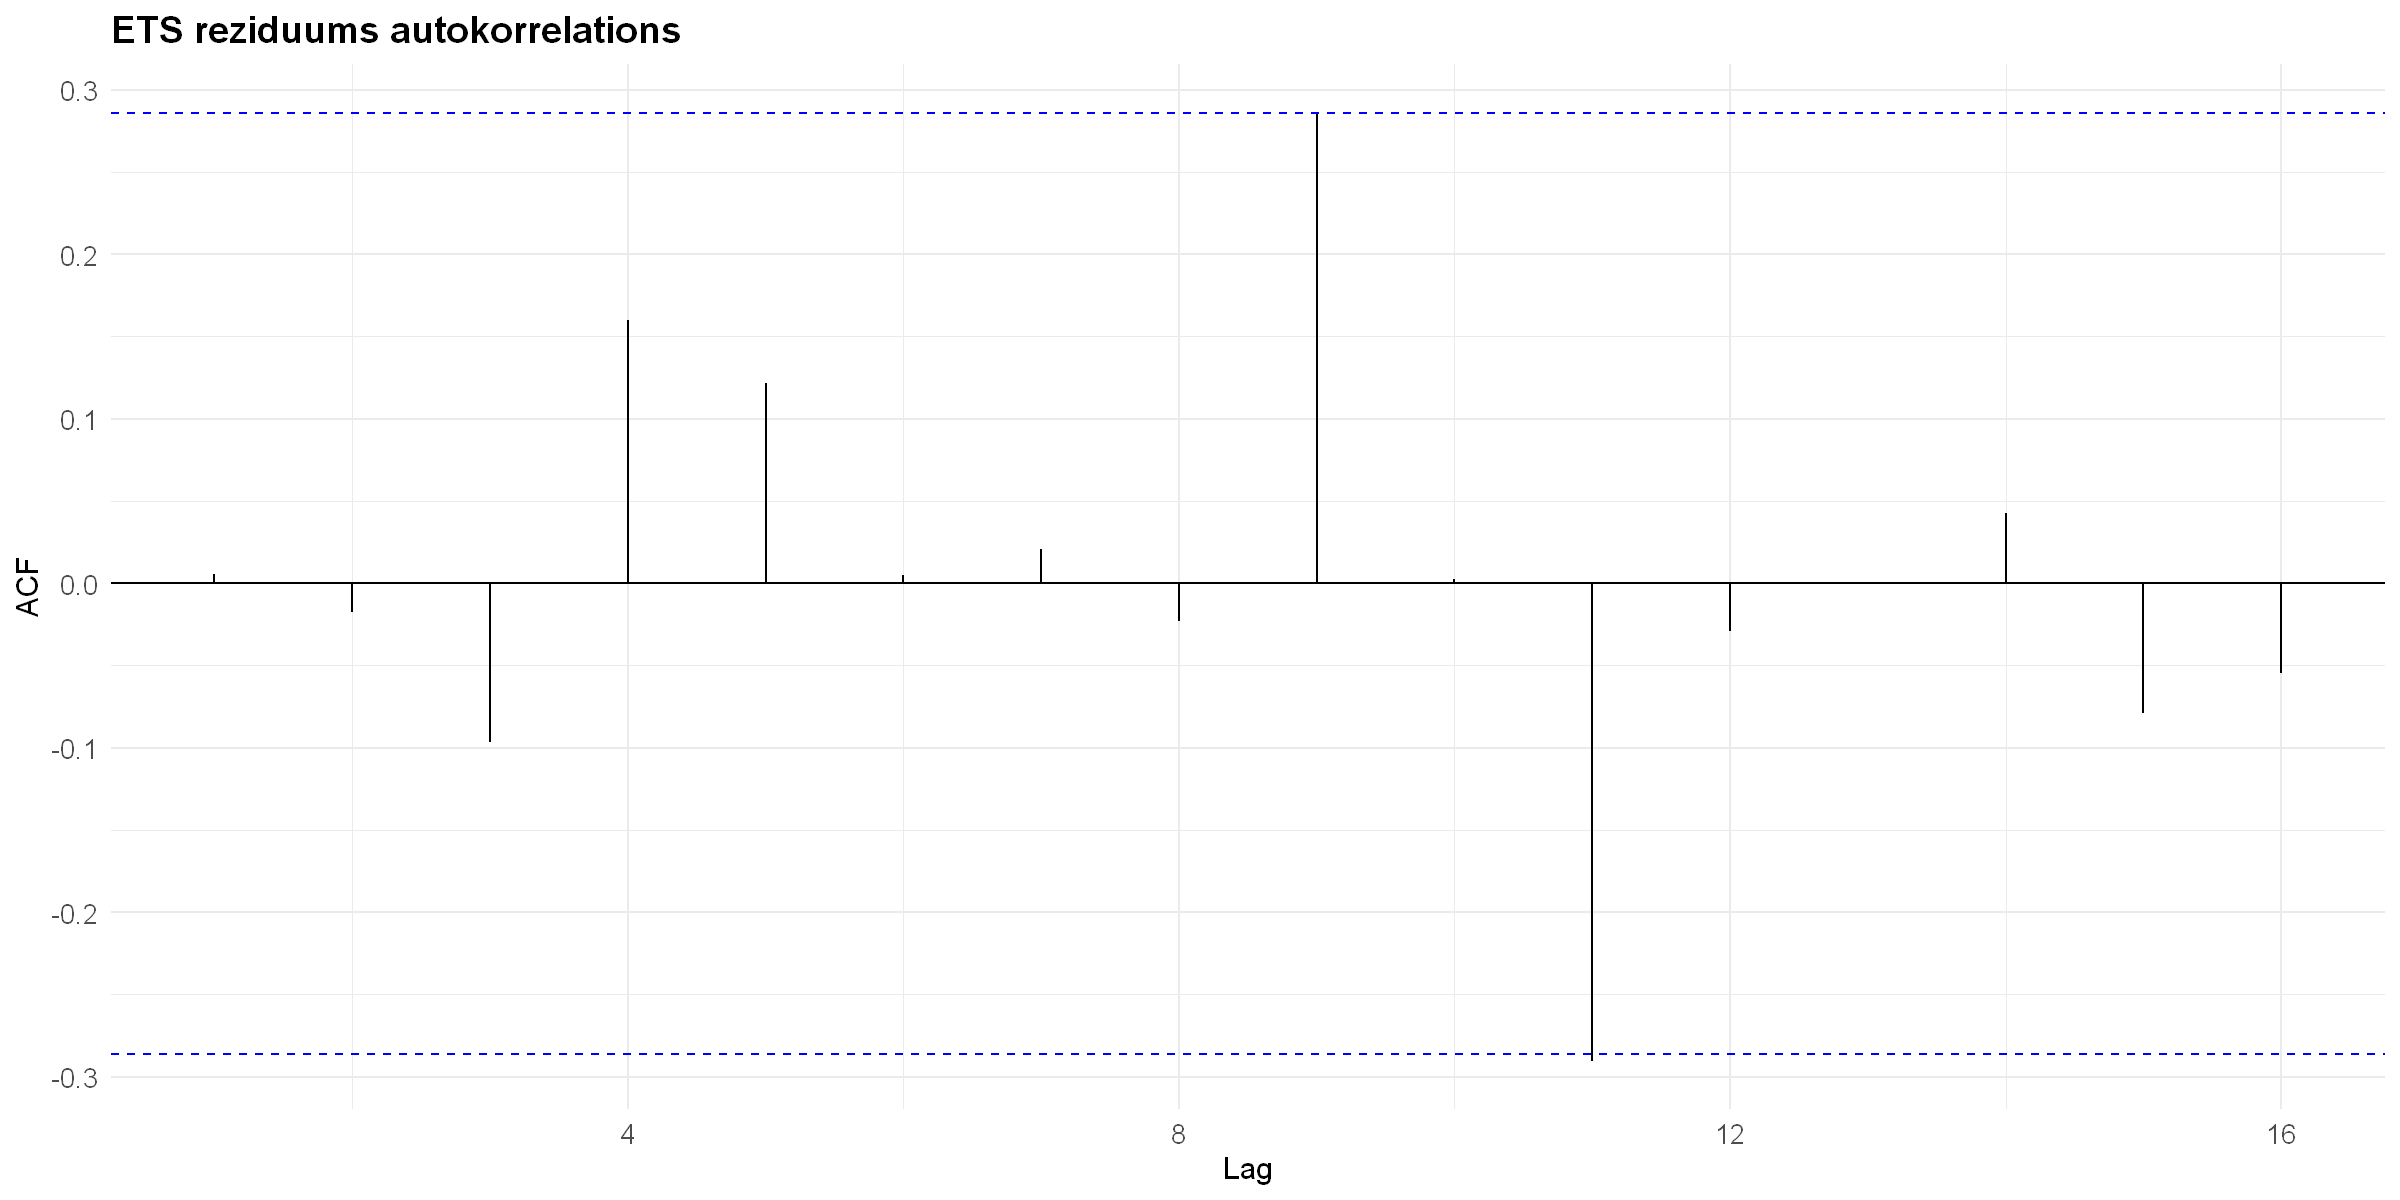

In [24]:
ets_residuals <- augment(fit_ets)

# 1. Reziduumok idősorbeli alakulása
ets_residuals %>%
  ggplot(aes(x = year, y = .resid)) +
  geom_line(color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "ETS modell reziduums",
    x = "Year",
    y = "Residuals"
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16)
  )

# 2. ACF a reziduumokra
ets_residuals %>%
  ACF(.resid) %>%
  autoplot() +
  labs(
    title = "ETS reziduums autokorrelations",
    x = "Lag",
    y = "ACF"
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16)
  )

# 3. Ljung-Box teszt
ets_residuals %>%
  features(.resid, ljung_box, lag = 10, dof = 0)

**Ábrák elemzése:**
- A reziduumok a nulla körül ingadoznak, nem mutatnak trendet vagy szezonális mintázatot, így a modell jól megragadja az idősor szerkezetét.
- Az ACF alapján nincs jelentős autokorreláció, a legtöbb érték a konfidencia sávon belül marad
- A Ljung–Box teszt (p ≈ 0.65) szerint a reziduumok függetlennek tekinthetők (fehér zaj).

**Következtetés:** az ETS modell megfelelő illeszkedést ad, és alkalmas előrejelzésre.

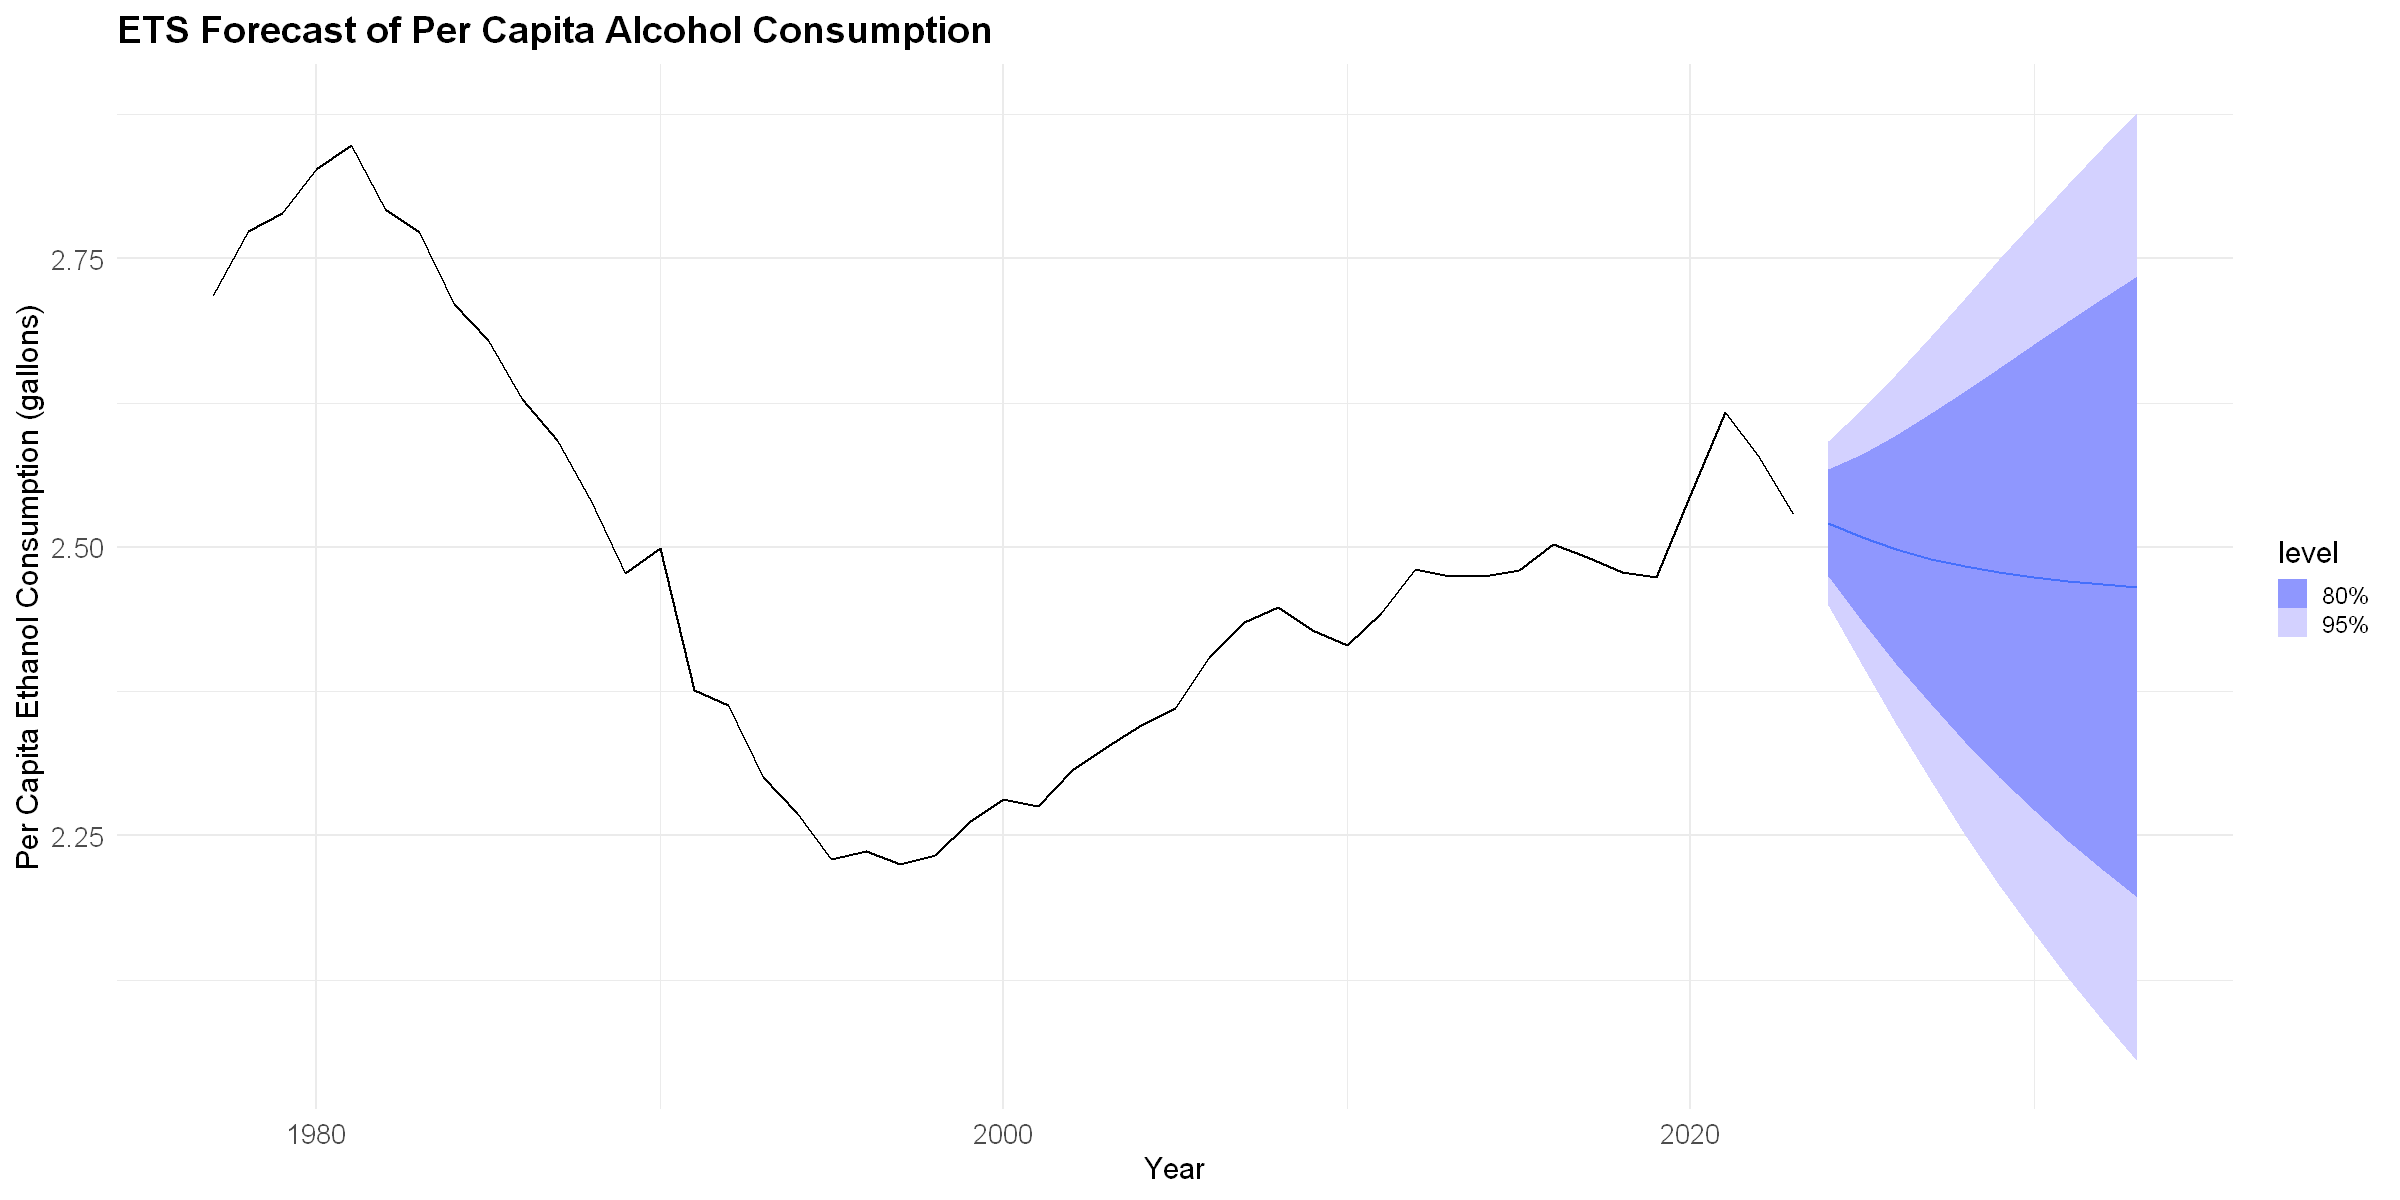

In [17]:
fc_ets <- fit_ets %>%
  forecast(h = 10)

ggtime::autoplot(fc_ets, df_us_ts) +
  labs(
    title = "ETS Forecast of Per Capita Alcohol Consumption",
    x = "Year",
    y = "Per Capita Ethanol Consumption (gallons)"
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16)
  )

# 3. TSLM - Time Series Linear Model modell

In [18]:
# TSLM modell illesztése
fit_tslm <- df_us_ts %>%
  model(TSLM(total ~ trend()))

report(fit_tslm)

Series: total 
Model: TSLM 

Residuals:
     Min       1Q   Median       3Q      Max 
-0.27913 -0.14742  0.01351  0.12047  0.26994 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.602920   0.048663  53.489  < 2e-16 ***
trend()     -0.004964   0.001765  -2.812  0.00726 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1642 on 45 degrees of freedom
Multiple R-squared: 0.1495,	Adjusted R-squared: 0.1306
F-statistic:  7.91 on 1 and 45 DF, p-value: 0.0072609


> **Értelmezés:**
>
> - Az **intercept (≈ 2.60)** a kiindulási szintet jelzi,
> - A **trend együttható (≈ -0.00496)** negatív, ami azt mutatja, hogy az alkoholfogyasztás hosszú távon enyhén csökkenő tendenciát követ.
>
> A trend paraméter statisztikailag szignifikáns (p < 0.01), így a csökkenő tendencia kimutatható.
>
> - **R² ≈ 0.15**, ami viszonylag alacsony magyarázóerőt jelez,
> - Ez arra utal, hogy a modell csak korlátozott mértékben képes megmagyarázni az adatok varianciáját.

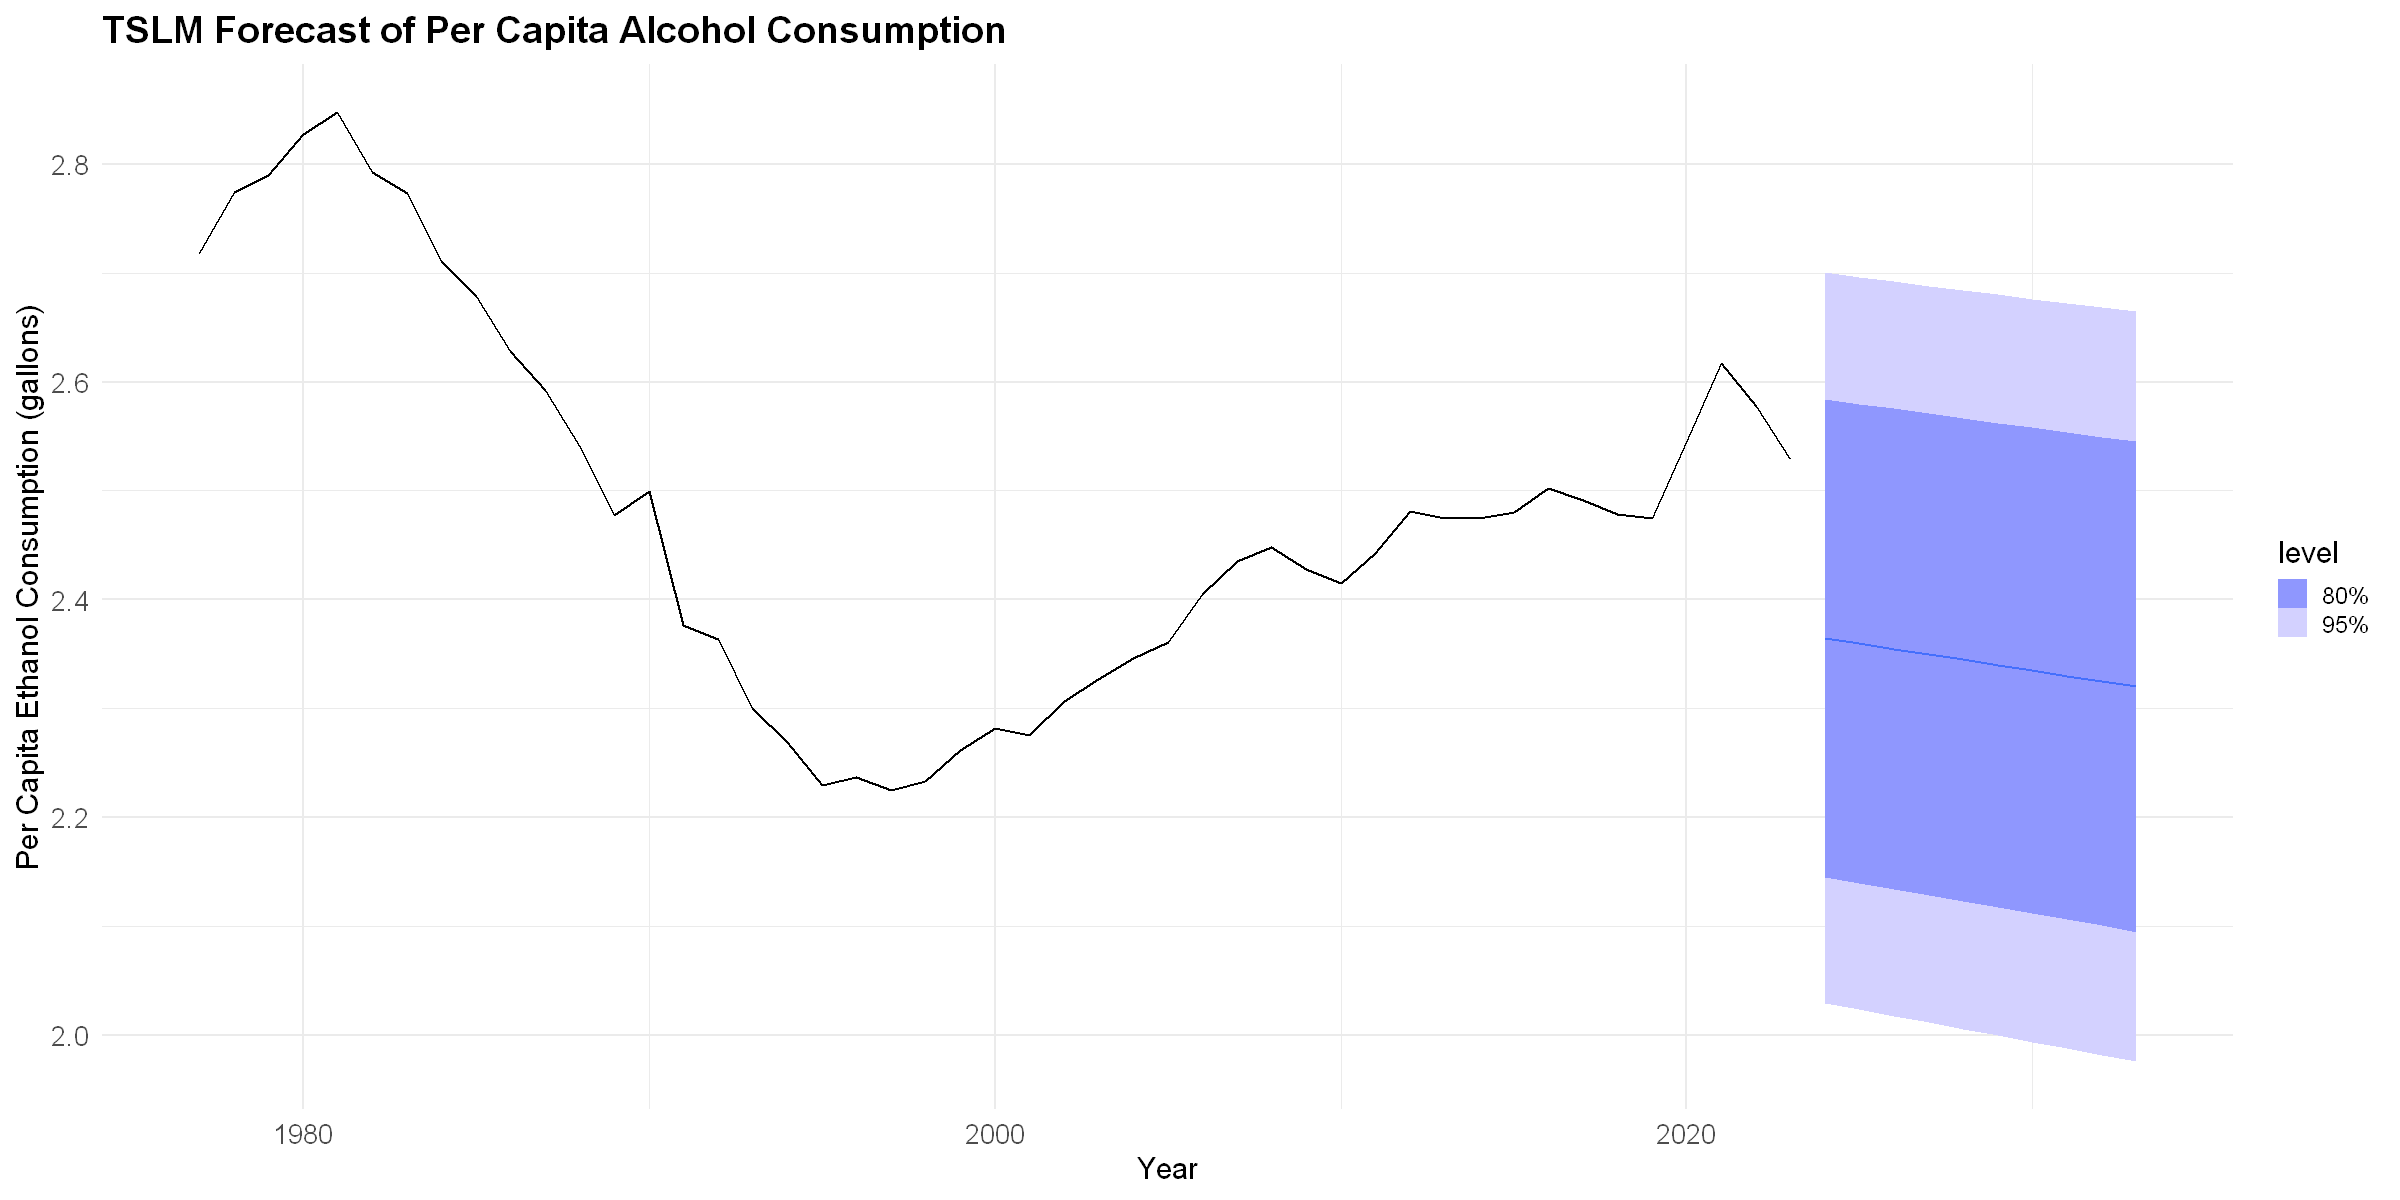

In [19]:
fc_tslm <- fit_tslm %>%
  forecast(h = 10)

ggtime::autoplot(fc_tslm, df_us_ts) +
  labs(
    title = "TSLM Forecast of Per Capita Alcohol Consumption",
    x = "Year",
    y = "Per Capita Ethanol Consumption (gallons)"
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold"),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16)
  )

# Modell-összehasonlítás

In [20]:
# Modellek közös objektumban
models <- df_us_ts %>%
  model(
    ARIMA = ARIMA(total),
    ETS   = ETS(total),
    TSLM  = TSLM(total ~ trend())
  )

print(glance(models))
accuracy(models) %>% as_tibble()

# A tibble: 3 × 20
  .model   sigma2 log_lik   AIC  AICc   BIC ar_roots  ma_roots      MSE     AMSE
  <chr>     <dbl>   <dbl> <dbl> <dbl> <dbl> <list>    <list>      <dbl>    <dbl>
1 ARIMA  0.00136     88.9 -168. -166. -158. <cpl [1]> <cpl>    NA       NA      
2 ETS    0.000207    68.8 -126. -124. -115. <NULL>    <NULL>    0.00118  0.00298
3 TSLM   0.0269      19.3 -166. -165. -160. <NULL>    <NULL>   NA       NA      
# ℹ 10 more variables: MAE <dbl>, r_squared <dbl>, adj_r_squared <dbl>,
#   statistic <dbl>, p_value <dbl>, df <int>, CV <dbl>, deviance <dbl>,
#   df.residual <int>, rank <int>


.model,.type,ME,RMSE,MAE,MPE,MAPE,MASE,RMSSE,ACF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARIMA,Training,-3.928262e-03,0.03525160,0.02690283,-0.1765691,1.075974,0.8608904,0.8990632,0.020819779
ETS,Training,-4.048203e-03,0.03437917,0.02567698,-0.1460213,1.030432,0.8216633,0.8768126,0.005455728
TSLM,Training,1.891875e-17,0.16062172,0.13647142,-0.4181398,5.545992,4.3670856,4.0965258,0.954762643


> A felosztás nagyjából 80–20%-os arányt biztosít a tanító és teszt adatok között. Ezért 2014 a határ.

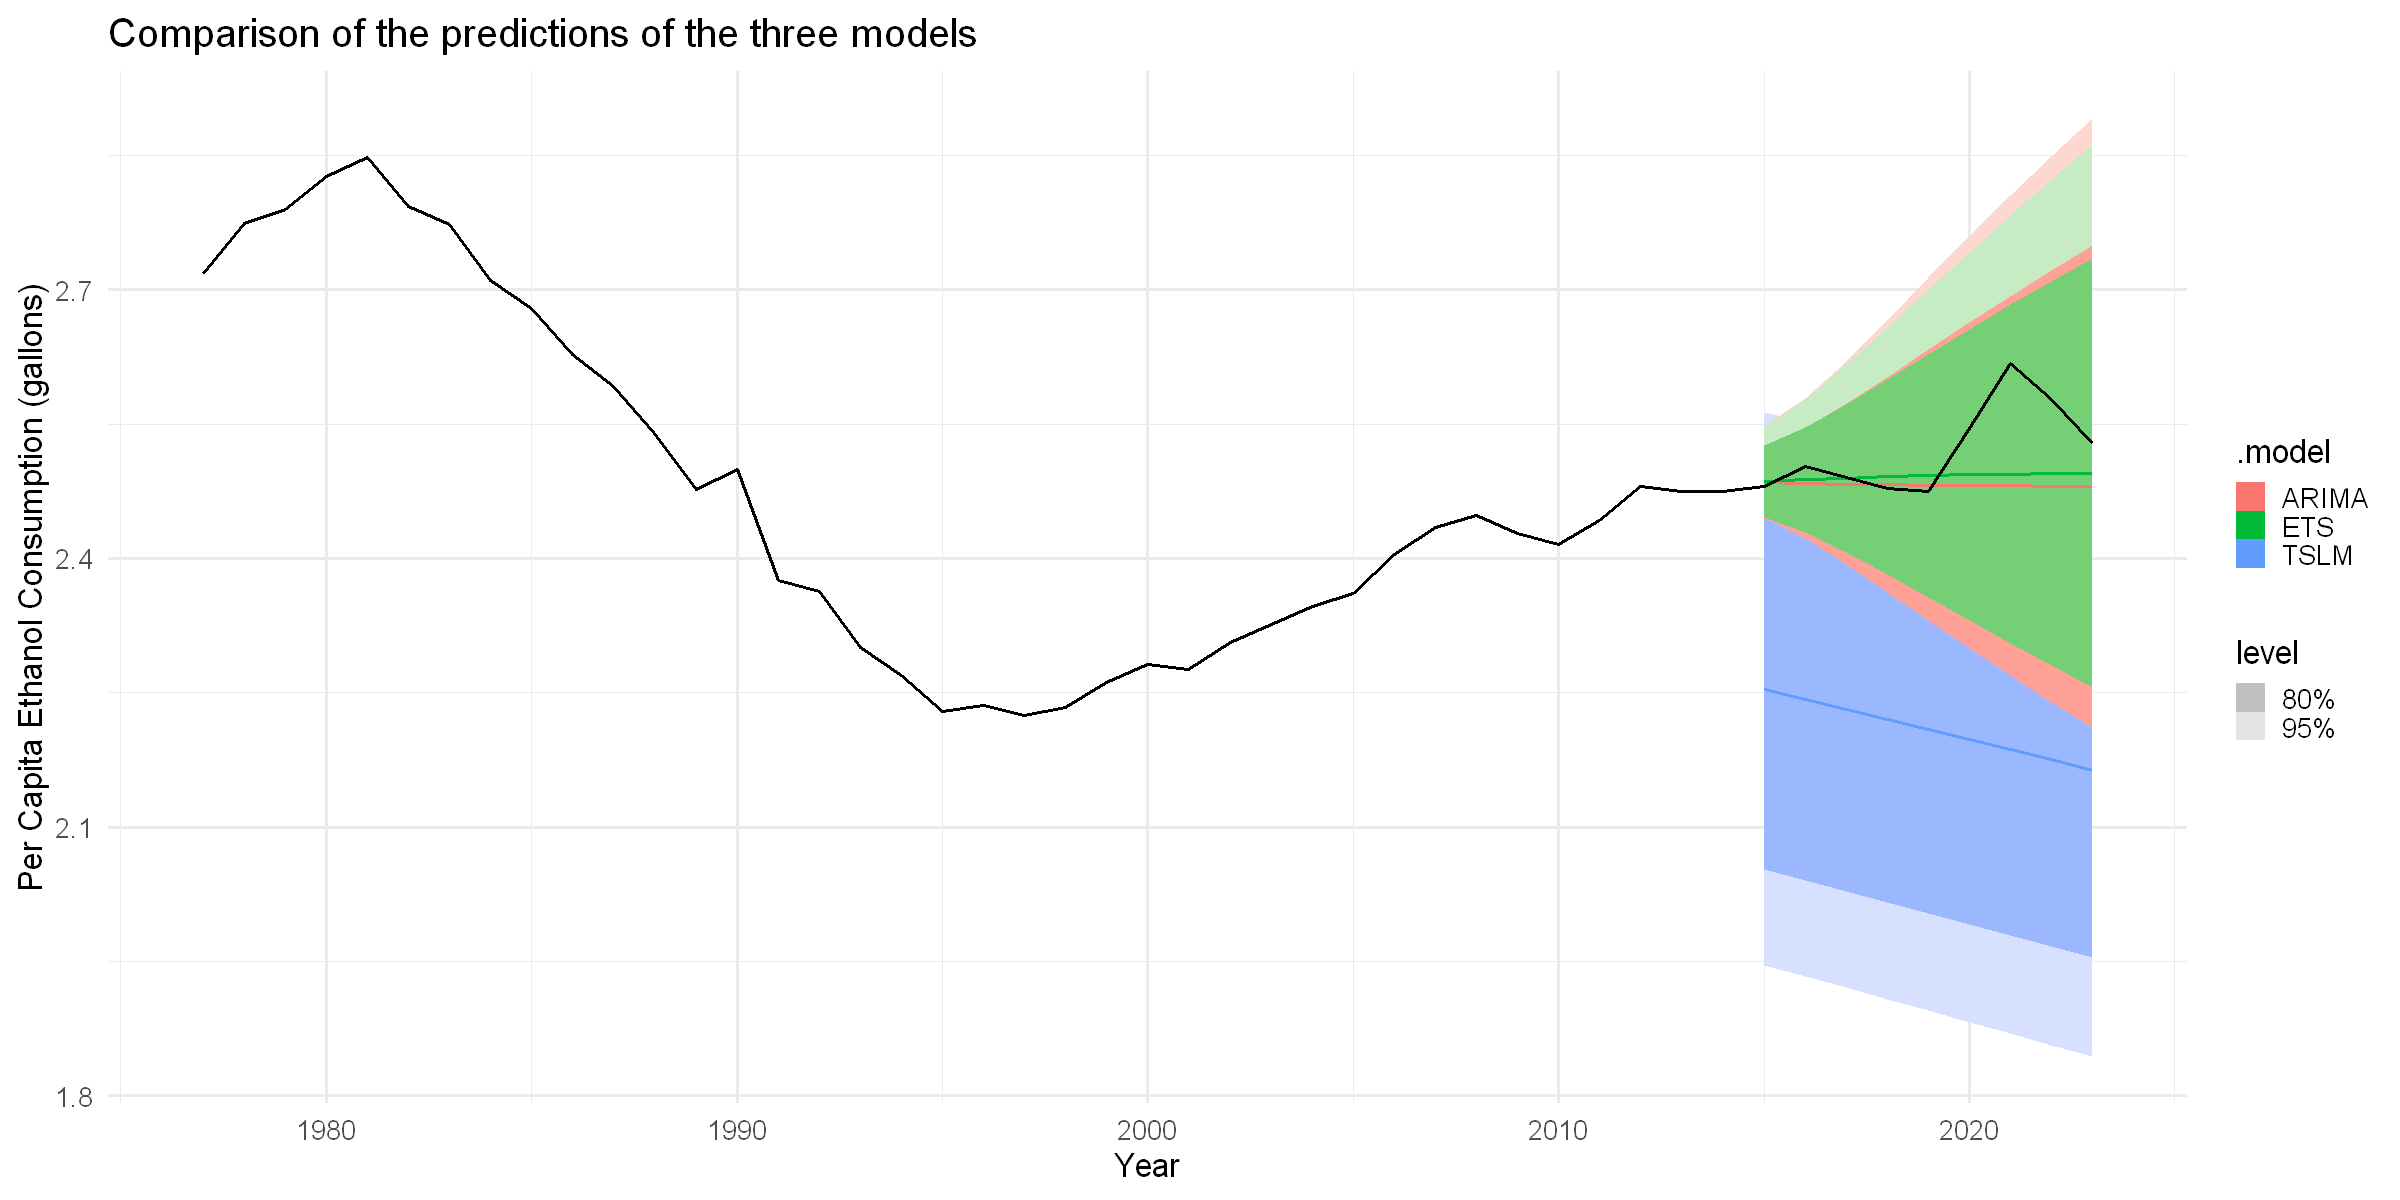

In [21]:
train <- df_us_ts %>% filter(year <= 2014)
test  <- df_us_ts %>% filter(year > 2014)

fit_models <- train %>%
  model(
    ARIMA = ARIMA(total),
    ETS   = ETS(total),
    TSLM  = TSLM(total ~ trend())
  )

fc_models <- fit_models %>%
  forecast(new_data = test)


fc_models %>%
  autoplot(df_us_ts) +
  labs(
    title = "Comparison of the predictions of the three models",
    x = "Year",
    y = "Per Capita Ethanol Consumption (gallons)"
  ) +
  theme_minimal(base_size = 20)

#### A három modell (**ARIMA**, **ETS** és **TSLM**) teljesítményét több mutató alapján hasonlítottam össze.


### Főbb megállapítások

### ❌ TSLM modell
- Jelentősen gyengébb teljesítményt nyújtott  
- Különösen magas értékek:
  - RMSE
  - MAE
  - MAPE  

 **Következtetés:**  
Az idősor nem írható le megfelelően egyszerű lineáris trenddel.


### ARIMA vs ETS

Mindkét modell jó eredményeket adott, azonban:

- **ETS modell**:
  -  Alacsonyabb RMSE  
  -  Alacsonyabb MAE  
  -  Legalacsonyabb MAPE  

 **Összességében enyhén jobb teljesítmény**

---

## Modellek értelmezése

### ARIMA
- Az idősor belső időbeli függőségeit modellezi  
- Jól kezeli:
  - autoregresszív kapcsolatok  
  - rövid távú dinamikát  



### ETS
- A sorozat:
  - **szintjét**
  - **trendjét**
- modellezi hatékonyan  

 Különösen jól működik stabil trend esetén



##  Végső következtetés

> **Az ETS modell bizonyult a legalkalmasabbnak az alkoholfogyasztás idősorának előrejelzésére.**

- Legjobb előrejelzési pontosság  
- Stabil viselkedés  

Ugyanakkor:  
Az **ARIMA** modell is versenyképes alternatíva, különösen akkor, ha az időbeli függőségek fontosabb szerepet játszanak.

---

## Összefoglalás röviden

| Modell | Értékelés |
|--------|----------|
| **ETS** | 🟢 Legjobb |
| **ARIMA** | 🟡 Jó alternatíva |
| **TSLM** | 🔴 Gyenge |